**Cell 01**

# Bangla News Framing: target-aware two-stage training

This notebook builds an interpretable system for comparing how Bangla news articles about the same event frame the government. It predicts sentence–aspect relevance first, predicts government-directed stance only for relevant pairs, aggregates probability-based article profiles, and compares same-event articles.

**Fixed design:** `csebuetnlp/banglabert`; six fixed political-news aspects; labels `NR`, `N`, `GF`, and `GC`; event-grouped splits; and no source, URL, article label, or identifier features in the sentence models. The annotations are AI-assisted and must not be presented as a fully human-verified gold standard.

**Cell 02**

## 1. Environment setup and reproducibility

Select a GPU runtime in Colab before running this section. The package command is rerunnable: packages already available in the runtime are retained when they satisfy the requirement.

In [1]:
# Cell 03
%pip install -q torch transformers datasets accelerate evaluate scikit-learn pandas numpy matplotlib seaborn pyarrow joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.3 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 04
import importlib.metadata as importlib_metadata
import json
import os
import platform
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from transformers import set_seed as set_transformers_seed

PACKAGE_NAMES = [
    "torch", "transformers", "datasets", "accelerate", "evaluate",
    "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn",
    "pyarrow", "joblib",
]
PACKAGE_VERSIONS = {
    name: importlib_metadata.version(name) for name in PACKAGE_NAMES
}

print(f"Python: {platform.python_version()}")
for name, version in PACKAGE_VERSIONS.items():
    print(f"{name}: {version}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA runtime reported by PyTorch: {torch.version.cuda}")

if not torch.cuda.is_available():
    raise RuntimeError(
        "No CUDA GPU is available. In Colab, choose Runtime > Change runtime "
        "type > GPU, reconnect, and rerun the notebook from the beginning."
    )

Python: 3.12.13
torch: 2.10.0+cu128
transformers: 5.0.0
datasets: 5.0.0
accelerate: 1.13.0
evaluate: 0.4.6
scikit-learn: 1.6.1
pandas: 2.3.3
numpy: 2.0.2
matplotlib: 3.10.0
seaborn: 0.13.2
pyarrow: 24.0.0
joblib: 1.5.3
CUDA available: True
GPU: Tesla T4
CUDA runtime reported by PyTorch: 12.8


**Cell 05**

## 2. Configuration, Drive paths, and deterministic seeds

All paths and initial hyperparameters are defined once here. Colab displays the folder as **My Drive**, while its mounted filesystem path is `/content/drive/MyDrive`.

In [4]:
# Cell 06
# Auto-detect Colab or Kaggle, configure paths, and set deterministic seeds.

import shutil

IN_COLAB = "google.colab" in sys.modules
IN_KAGGLE = Path("/kaggle/input").is_dir()

SEED = 42

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

    EXECUTION_ENVIRONMENT = "colab"
    PROJECT_ROOT = Path(
        "/content/drive/MyDrive/bangla-news-framing"
    )
    DATA_PATH = (
        PROJECT_ROOT
        / "data"
        / "raw"
        / "banglabias_sentence_annotations_completed.csv"
    )
    OUTPUT_DIR = PROJECT_ROOT / "artifacts"

elif IN_KAGGLE:
    EXECUTION_ENVIRONMENT = "kaggle"
    KAGGLE_INPUT_ROOT = Path("/kaggle/input")
    PROJECT_ROOT = Path(
        "/kaggle/working/bangla-news-framing"
    )

    data_matches = list(
        KAGGLE_INPUT_ROOT.rglob(
            "banglabias_sentence_annotations_completed.csv"
        )
    )

    if len(data_matches) != 1:
        raise FileNotFoundError(
            "Expected exactly one completed annotation CSV under "
            f"{KAGGLE_INPUT_ROOT}, but found {len(data_matches)}: "
            f"{data_matches}"
        )

    DATA_PATH = data_matches[0]

    # Expected uploaded layout:
    # bangla-news-framing/data/raw/<CSV>
    INPUT_PROJECT_ROOT = DATA_PATH.parents[2]
    INPUT_ARTIFACT_DIR = INPUT_PROJECT_ROOT / "artifacts"
    OUTPUT_DIR = PROJECT_ROOT / "artifacts"

    if not INPUT_ARTIFACT_DIR.is_dir():
        raise FileNotFoundError(
            "Kaggle artifact directory was not found at "
            f"{INPUT_ARTIFACT_DIR}. Upload the data and artifacts "
            "using the original project folder structure."
        )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    # Kaggle inputs are read-only. Copy only the two final models,
    # not large training-checkpoint directories.
    for model_directory_name in [
        "relevance_model",
        "stance_model",
    ]:
        source_model_directory = (
            INPUT_ARTIFACT_DIR / model_directory_name
        )
        destination_model_directory = (
            OUTPUT_DIR / model_directory_name
        )

        if not source_model_directory.is_dir():
            raise FileNotFoundError(
                f"Missing saved model: {source_model_directory}"
            )

        shutil.copytree(
            source_model_directory,
            destination_model_directory,
            dirs_exist_ok=True,
        )

    # Preserve small root-level JSON, CSV, and Parquet artifacts when
    # they are included in the private Kaggle dataset.
    for artifact_file in INPUT_ARTIFACT_DIR.iterdir():
        if artifact_file.is_file():
            shutil.copy2(
                artifact_file,
                OUTPUT_DIR / artifact_file.name,
            )

else:
    raise RuntimeError(
        "Unsupported runtime. Run this notebook in Google Colab "
        "or Kaggle."
    )


CONFIG = {
    "model_name": "csebuetnlp/banglabert",
    "seed": SEED,
    "data_path": str(DATA_PATH),
    "output_dir": str(OUTPUT_DIR),
    "max_length": 128,
    "learning_rate": 2e-5,
    "train_batch_size": 16,
    "eval_batch_size": 32,
    "max_epochs": 5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.10,
    "early_stopping_patience": 2,
}


def set_all_seeds(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(
        True,
        warn_only=True,
    )
    set_transformers_seed(seed)


set_all_seeds(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Preserve the project "
        "folder structure and rerun this cell."
    )

ENVIRONMENT = {
    "execution_environment": EXECUTION_ENVIRONMENT,
    "python": platform.python_version(),
    "platform": platform.platform(),
    "cuda_available": torch.cuda.is_available(),
    "gpu": (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else None
    ),
    "pytorch_cuda": torch.version.cuda,
    "packages": PACKAGE_VERSIONS,
}

with (OUTPUT_DIR / "config.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        CONFIG,
        file,
        ensure_ascii=False,
        indent=2,
    )

with (OUTPUT_DIR / "environment.json").open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        ENVIRONMENT,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Execution environment:", EXECUTION_ENVIRONMENT)
print("Dataset:", DATA_PATH)
print("Writable artifacts:", OUTPUT_DIR)
print(json.dumps(CONFIG, indent=2, ensure_ascii=False))

Execution environment: kaggle
Dataset: /kaggle/input/datasets/apusharma45/bangla-news-framing/bangla-news-framing/data/raw/banglabias_sentence_annotations_completed.csv
Writable artifacts: /kaggle/working/bangla-news-framing/artifacts
{
  "model_name": "csebuetnlp/banglabert",
  "seed": 42,
  "data_path": "/kaggle/input/datasets/apusharma45/bangla-news-framing/bangla-news-framing/data/raw/banglabias_sentence_annotations_completed.csv",
  "output_dir": "/kaggle/working/bangla-news-framing/artifacts",
  "max_length": 128,
  "learning_rate": 2e-05,
  "train_batch_size": 16,
  "eval_batch_size": 32,
  "max_epochs": 5,
  "weight_decay": 0.01,
  "warmup_ratio": 0.1,
  "early_stopping_patience": 2
}


**Cell 07**

## 3. Load and strictly validate the annotation CSV

The source CSV remains unchanged. Empty strings are preserved during loading, and assertions stop execution if the file differs from the authoritative schema or expected dataset statistics.

In [5]:
# Cell 08
EXPECTED_COLUMNS = [
    "article_id",
    "event_name",
    "news_headline",
    "news_source",
    "publication_date",
    "source_link",
    "article_stance",
    "sentence_id",
    "sentence_index",
    "sentence_section",
    "sentence_text",
    "a1_policy_administration",
    "a2_accountability_justice",
    "a3_security_civil_rights",
    "a4_democracy_mobilization",
    "a5_economy_development",
    "a6_welfare_social_environment",
    "stance_holder",
    "is_quote",
]
ASPECT_COLUMNS = EXPECTED_COLUMNS[11:17]
ALLOWED_ASPECT_LABELS = {"NR", "N", "GF", "GC"}
ALLOWED_ARTICLE_LABELS = {"Govt critique", "Neutral", "Govt leaning"}
ALLOWED_SECTIONS = {"headline", "lead", "body"}
ALLOWED_STANCE_HOLDERS = {
    "journalist", "government", "opposition", "law_enforcement",
    "court", "expert", "activist", "citizen", "victim_or_family",
    "organization", "unclear",
}

df = pd.read_csv(DATA_PATH, encoding="utf-8", keep_default_na=False)
print(f"Loaded {len(df):,} rows and {df.shape[1]} columns from {DATA_PATH}")
display(pd.DataFrame({"dtype": df.dtypes.astype(str)}))

Loaded 5,308 rows and 19 columns from /kaggle/input/datasets/apusharma45/bangla-news-framing/bangla-news-framing/data/raw/banglabias_sentence_annotations_completed.csv


,dtype
article_id,int64
event_name,object
news_headline,object
news_source,object
publication_date,object
source_link,object
article_stance,object
sentence_id,object
sentence_index,int64
sentence_section,object


In [6]:
# Cell 09
def blank_count(frame: pd.DataFrame) -> int:
    return int(frame.astype(str).apply(lambda column: column.str.strip().eq("").sum()).sum())

assert df.columns.tolist() == EXPECTED_COLUMNS, (
    "Unexpected schema or column order.\n"
    f"Expected: {EXPECTED_COLUMNS}\nFound: {df.columns.tolist()}"
)
assert df.shape == (5308, 19), f"Expected shape (5308, 19), found {df.shape}"
assert df["article_id"].nunique() == 118, "Expected 118 unique articles"
assert df["event_name"].nunique() == 26, "Expected 26 unique events"
assert df["sentence_id"].duplicated().sum() == 0, "Duplicate sentence_id values found"
assert df["sentence_text"].str.strip().ne("").all(), "Blank sentence_text found"
assert blank_count(df) == 0, "Unexpected blank cells found in the completed dataset"
assert set(df["article_stance"].unique()) == ALLOWED_ARTICLE_LABELS
assert set(df["sentence_section"].unique()) == ALLOWED_SECTIONS
assert set(df["stance_holder"].unique()) == ALLOWED_STANCE_HOLDERS
assert set(df["is_quote"].unique()) == {0, 1}
assert df.groupby("article_id")["event_name"].nunique().max() == 1
assert df.groupby("article_id")["article_stance"].nunique().max() == 1

for column in ASPECT_COLUMNS:
    found_labels = set(df[column].unique())
    assert found_labels == ALLOWED_ASPECT_LABELS, (
        f"{column}: expected {sorted(ALLOWED_ASPECT_LABELS)}, "
        f"found {sorted(found_labels)}"
    )

article_six_dates = set(
    df.loc[df["article_id"].astype(str).eq("6"), "publication_date"].astype(str)
)
assert article_six_dates == {"2023-09-23"}, (
    f"Article 6 must have corrected date 2023-09-23; found {article_six_dates}"
)

article_rows = df.drop_duplicates("article_id")
audit_summary = {
    "rows": len(df),
    "columns": df.shape[1],
    "articles": int(df["article_id"].nunique()),
    "events": int(df["event_name"].nunique()),
    "duplicate_sentence_ids": int(df["sentence_id"].duplicated().sum()),
    "blank_sentence_texts": int(df["sentence_text"].str.strip().eq("").sum()),
    "blank_cells": blank_count(df),
}
display(pd.Series(audit_summary, name="value").to_frame())
print("All schema and integrity assertions passed.")

,value
rows,5308
columns,19
articles,118
events,26
duplicate_sentence_ids,0
blank_sentence_texts,0
blank_cells,0


All schema and integrity assertions passed.


**Cell 10**

## 4. Initial data audit and class imbalance

Article labels are counted once per article. Aspect labels are counted over sentence rows. Accuracy will not be treated as the primary metric because `NR` dominates relevance and `N` dominates relevant-pair stance.

In [7]:
# Cell 11
article_label_counts = (
    article_rows["article_stance"]
    .value_counts()
    .reindex(["Govt leaning", "Neutral", "Govt critique"])
)
section_counts = (
    df["sentence_section"]
    .value_counts()
    .reindex(["headline", "lead", "body"])
)
aspect_label_counts = pd.DataFrame({
    column: df[column].value_counts() for column in ASPECT_COLUMNS
}).T.reindex(columns=["NR", "N", "GF", "GC"]).fillna(0).astype(int)
aspect_label_percentages = aspect_label_counts.div(
    aspect_label_counts.sum(axis=1), axis=0
).mul(100).round(2)

assert article_label_counts.to_dict() == {
    "Govt leaning": 33, "Neutral": 45, "Govt critique": 40
}
assert section_counts.to_dict() == {"headline": 118, "lead": 118, "body": 5072}
assert aspect_label_counts.sum().to_dict() == {
    "NR": 24630, "N": 6882, "GF": 108, "GC": 228
}

print("Article labels (one row per article)")
display(article_label_counts.rename("count").to_frame())
print("Sentence sections")
display(section_counts.rename("count").to_frame())
print("Aspect-label counts")
display(aspect_label_counts)
print("Aspect-label percentages")
display(aspect_label_percentages)

Article labels (one row per article)


,count
article_stance,
Govt leaning,33
Neutral,45
Govt critique,40


Sentence sections


,count
sentence_section,
headline,118
lead,118
body,5072


Aspect-label counts


,NR,N,GF,GC
a1_policy_administration,3983,1219,40,66
a2_accountability_justice,4424,835,5,44
a3_security_civil_rights,4398,860,8,42
a4_democracy_mobilization,4000,1255,13,40
a5_economy_development,3769,1503,23,13
a6_welfare_social_environment,4056,1210,19,23


Aspect-label percentages


,NR,N,GF,GC
a1_policy_administration,75.04,22.97,0.75,1.24
a2_accountability_justice,83.35,15.73,0.09,0.83
a3_security_civil_rights,82.86,16.20,0.15,0.79
a4_democracy_mobilization,75.36,23.64,0.24,0.75
a5_economy_development,71.01,28.32,0.43,0.24
a6_welfare_social_environment,76.41,22.80,0.36,0.43


In [ ]:
# Cell 12
sentence_lengths = df["sentence_text"].str.len()
length_summary = sentence_lengths.describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)
print("Sentence length in Unicode characters")
display(length_summary.rename("characters").to_frame())

for section in ["headline", "lead", "body"]:
    print(f"Examples — {section}")
    display(
        df.loc[df["sentence_section"].eq(section), ["sentence_id", "sentence_text"]]
        .head(3)
        .style.set_properties(subset=["sentence_text"], **{"text-align": "left"})
    )

Sentence length in Unicode characters


,characters
count,5308.00
mean,90.17
std,59.01
min,10.00
25%,52.00
50%,77.00
75%,114.00
90%,158.00
95%,194.00
99%,300.79


Examples — headline


,sentence_id,sentence_text
0,2_H,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন পি যেভাবে গনতন্ত্র ধ্বংস করেছিল
41,4_H,"শাহবাগের সেই ‘গণজাগরণ মঞ্চ’ এখন কোথায়, কী করছে?"
70,5_H,বাঙালির ঐক্যবদ্ধ জাগরণের নাম শাহবাগ


Examples — lead


,sentence_id,sentence_text
1,2_S001,"২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ছাত্র জনতার ত্যাগের বিনিময়ে দেশে গণতন্ত্র বিকাশের যে সুযোগ সৃষ্টি হয়েছিল তাকে কবরস্থ করার কফিন তৈরি করেছিল বি এন পি, আওয়ামী লীগ সেটাকে পেরেক মেরে কবরস্ত করেছে।"
42,4_S001,বাংলাদেশে ১৯৭১ সালের মানবতাবিরোধী অপরাধীদের মৃত্যুদণ্ডের দাবিতে গড়ে ওঠা ‘গণজাগরণ মঞ্চের’ পাঁচ বছরপূর্তি হলো আজ।
71,5_S001,"বাঙালির জাগরণ ঘটেছে যুগে যুগে, ব্রিটিশবিরোধী আন্দোলন থেকে মহান ভাষা আন্দোলন, ৬ দফা, ৬৯-এর গণ-অভ্যুত্থান, ৭০-এর নির্বাচন, ৭১-এর অসহযোগ আন্দোলন এবং মহান মুক্তিযুদ্ধ, ৯০-এর স্বৈরাচারবিরোধী আন্দোলন, সর্বশেষ ২০১৩-এর শাহবাগ আন্দোলন।"


Examples — body


,sentence_id,sentence_text
2,2_S002,ভুলে গেলে চলবে না।
3,2_S003,"গণহত্যাকারী, ফ্যাসিস্ট, খুনি আওয়ামী লীগ একাই এই পথে আসেনি, বি এন পি’র দায়ও কম না, বি এন পি পথ তৈরি করে দিয়েছিল, আওয়ামী লীগ সেই পথে এগিয়ে গন্তব্যে পৌঁছেছে।।"
4,2_S004,"শেখ হাসিনা ২০০১ সালে ইতিহাসের সবচেয়ে শান্তিপূর্ণ উপায়ে ক্ষমতা ছেড়েছিল, এটাও ইতিহাসের অংশ।"


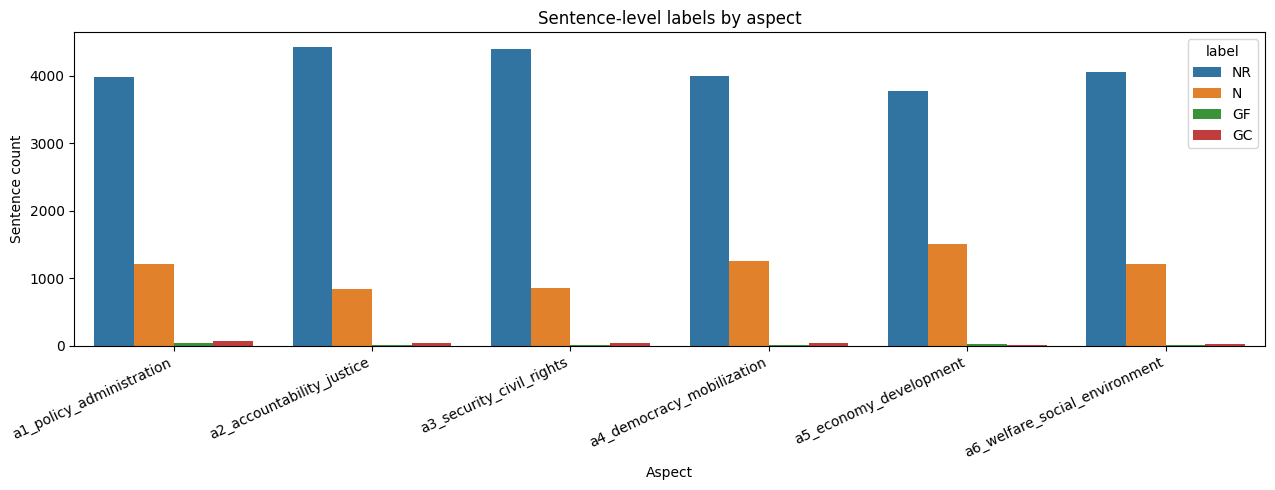

Saved configuration, environment, and audit metadata to /content/drive/MyDrive/bangla-news-framing/artifacts


In [ ]:
# Cell 13
plot_data = (
    aspect_label_counts
    .rename_axis("aspect_column")
    .reset_index()
    .melt(id_vars="aspect_column", var_name="label", value_name="count")
)
plt.figure(figsize=(13, 5))
sns.barplot(
    data=plot_data, x="aspect_column", y="count", hue="label",
    hue_order=["NR", "N", "GF", "GC"],
)
plt.title("Sentence-level labels by aspect")
plt.xlabel("Aspect")
plt.ylabel("Sentence count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

audit_report = {
    **audit_summary,
    "article_label_counts": {key: int(value) for key, value in article_label_counts.items()},
    "sentence_section_counts": {key: int(value) for key, value in section_counts.items()},
    "aspect_label_counts": {
        aspect: {label: int(value) for label, value in counts.items()}
        for aspect, counts in aspect_label_counts.to_dict(orient="index").items()
    },
    "sentence_length_characters": {
        key: float(value) for key, value in length_summary.items()
    },
}
with (OUTPUT_DIR / "data_audit.json").open("w", encoding="utf-8") as file:
    json.dump(audit_report, file, ensure_ascii=False, indent=2)

print(f"Saved configuration, environment, and audit metadata to {OUTPUT_DIR}")

**Cell 14**

### Step 1 checkpoint

The runtime, paths, dataset schema, integrity, and documented distributions have been verified.

**Cell 15**

## 5. Explicit Bangla text preprocessing

Preprocessing is deliberately visible and conservative. The original `sentence_text` is never overwritten; the model receives a new `sentence_text_clean` column.

| Operation | Why it is applied |
|---|---|
| Decode HTML entities and remove actual HTML tags | Remove web-page artifacts without deleting ordinary angle-free text |
| Unicode NFC normalization | Give canonically equivalent Unicode sequences one representation |
| Remove zero-width/BOM artifacts | Prevent invisible characters from creating inconsistent tokens |
| Remove URLs | URLs are not useful stance evidence here; removal is consistent and recorded |
| Collapse line breaks, tabs, and repeated whitespace | Remove formatting differences while preserving word order |

We **do not** remove Bangla stopwords, stem/lemmatize, lowercase, translate, remove all punctuation, or re-segment sentences. Negation, names, numbers, punctuation, sentence IDs, and raw text are preserved. The optional external Bangla normalizer is not used, so every transformation is shown below.

In [8]:
# Cell 16
import html
import re
import unicodedata

HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
URL_PATTERN = re.compile(
    r"(?:https?://|www\.)\S+",
    flags=re.IGNORECASE,
)
WHITESPACE_PATTERN = re.compile(r"\s+")

ZERO_WIDTH_CHARACTERS = "\u200b\u200c\u200d\ufeff"
ZERO_WIDTH_TRANSLATION = str.maketrans(
    "",
    "",
    ZERO_WIDTH_CHARACTERS,
)

# URLs are represented consistently instead of being deleted.
URL_PLACEHOLDER = "[URL]"


def clean_bangla_text(text: str) -> str:
    """
    Conservatively clean web and Unicode artifacts for BanglaBERT.

    The function preserves Bangla words, names, numbers, negation,
    punctuation, and sentence boundaries.
    """
    cleaned = str(text)

    # Convert entities such as &amp; into their actual characters.
    cleaned = html.unescape(cleaned)

    # Remove actual HTML tags without removing normal punctuation.
    cleaned = HTML_TAG_PATTERN.sub(" ", cleaned)

    # Normalize canonically equivalent Unicode representations.
    cleaned = unicodedata.normalize("NFC", cleaned)

    # Remove invisible formatting artifacts.
    cleaned = cleaned.translate(ZERO_WIDTH_TRANSLATION)

    # A placeholder prevents URL-only rows from becoming empty.
    cleaned = URL_PATTERN.sub(
        f" {URL_PLACEHOLDER} ",
        cleaned,
    )

    # Normalize line breaks, tabs, and repeated spaces.
    cleaned = WHITESPACE_PATTERN.sub(" ", cleaned).strip()

    return cleaned


# Preserve a separate copy to confirm that the raw text is unchanged.
raw_sentence_text = df["sentence_text"].copy(deep=True)

df["sentence_text_clean"] = (
    df["sentence_text"]
    .map(clean_bangla_text)
)

changed_mask = df["sentence_text"].ne(
    df["sentence_text_clean"]
)

empty_after_cleaning = df[
    df["sentence_text_clean"].str.strip().eq("")
]

# If a future dataset produces empty text, show the responsible rows.
if not empty_after_cleaning.empty:
    display(
        empty_after_cleaning[
            ["sentence_id", "sentence_text", "sentence_text_clean"]
        ]
    )
    raise AssertionError(
        "Cleaning produced one or more empty sentences."
    )

cleaning_audit = {
    "url_policy": "replace with [URL]",
    "url_placeholder": URL_PLACEHOLDER,
    "rows_before": int(len(df)),
    "rows_after": int(len(df)),
    "rows_changed": int(changed_mask.sum()),
    "rows_unchanged": int((~changed_mask).sum()),
    "empty_after_cleaning": int(
        df["sentence_text_clean"].str.strip().eq("").sum()
    ),
    "raw_rows_containing_url": int(
        df["sentence_text"]
        .str.contains(URL_PATTERN)
        .sum()
    ),
    "raw_rows_containing_html_tag": int(
        df["sentence_text"]
        .str.contains(HTML_TAG_PATTERN)
        .sum()
    ),
    "raw_rows_containing_zero_width": int(
        df["sentence_text"]
        .apply(
            lambda text: any(
                character in str(text)
                for character in ZERO_WIDTH_CHARACTERS
            )
        )
        .sum()
    ),
}

# Integrity assertions
assert len(df) == 5308, (
    "Cleaning must not add or remove sentence rows."
)
assert df["sentence_text"].equals(raw_sentence_text), (
    "Raw sentence text was modified."
)
assert df["sentence_text_clean"].str.strip().ne("").all(), (
    "Cleaning produced an empty sentence."
)
assert df["sentence_id"].nunique() == 5308, (
    "Sentence IDs changed during cleaning."
)

display(
    pd.Series(
        cleaning_audit,
        name="value",
    ).to_frame()
)

examples_to_show = df.loc[
    changed_mask,
    [
        "sentence_id",
        "sentence_text",
        "sentence_text_clean",
    ],
].head(10)

if examples_to_show.empty:
    print(
        "No rows required cleaning; showing unchanged "
        "examples for verification."
    )
    examples_to_show = df[
        [
            "sentence_id",
            "sentence_text",
            "sentence_text_clean",
        ]
    ].head(5)

display(examples_to_show)

with (
    OUTPUT_DIR / "preprocessing_audit.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        cleaning_audit,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Preprocessing completed successfully.")

,value
url_policy,replace with [URL]
url_placeholder,[URL]
rows_before,5308
rows_after,5308
rows_changed,3748
rows_unchanged,1560
empty_after_cleaning,0
raw_rows_containing_url,1
raw_rows_containing_html_tag,0
raw_rows_containing_zero_width,82


,sentence_id,sentence_text,sentence_text_clean
1,2_S001,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...
3,2_S003,"গণহত্যাকারী, ফ্যাসিস্ট, খুনি আওয়ামী লীগ একাই এ...","গণহত্যাকারী, ফ্যাসিস্ট, খুনি আওয়ামী লীগ একাই ..."
6,2_S006,২০০১-২০০৬ জামানায় তারাও মাঝারি মানের ফ্যাসিজম...,২০০১-২০০৬ জামানায় তারাও মাঝারি মানের ফ্যাসিজম...
7,2_S007,"আওয়ামী লীগ প্রমানিত ফ্যাসিস্ট, গনহত্যাকারী।","আওয়ামী লীগ প্রমানিত ফ্যাসিস্ট, গনহত্যাকারী।"
10,2_S010,জনগণের সামনে সুযোগ এসেছে আওয়ামী লীগ ও বি এন পি...,জনগণের সামনে সুযোগ এসেছে আওয়ামী লীগ ও বি এন প...
12,2_S012,সেজন্য সাধারন মানুষ আওয়ামী লীগের জামানায় দীর্ঘ...,সেজন্য সাধারন মানুষ আওয়ামী লীগের জামানায় দীর...
46,4_S005,কিন্তু এখন এই আন্দোলন তেমন করে আর চোখে পড়ে না।,কিন্তু এখন এই আন্দোলন তেমন করে আর চোখে পড়ে না।
72,5_S002,এটা নিশ্চিত করে বলা যায় মুক্তিযুদ্ধের সপক্ষের ...,এটা নিশ্চিত করে বলা যায় মুক্তিযুদ্ধের সপক্ষের...
74,5_S004,"সেদিন ছিল ৫ ফেব্রুয়ারি মঙ্গলবার, একে অপরের হাত...","সেদিন ছিল ৫ ফেব্রুয়ারি মঙ্গলবার, একে অপরের হা..."
75,5_S005,"যে তরুণ প্রজন্মের বিরুদ্ধে অনেক অভিযোগ, সেই প্...","যে তরুণ প্রজন্মের বিরুদ্ধে অনেক অভিযোগ, সেই প্..."


Preprocessing completed successfully.


**Cell 17**

## 6. Fixed aspect and label mappings

The model is target-aware: every sentence is paired with one complete Bangla aspect description. Supplying `A1` alone would carry no semantic meaning for BanglaBERT, whereas the full description tells the encoder which government-related target to assess.

In [9]:
# Cell 18
ASPECTS = [
    {
        "aspect_id": "A1",
        "aspect_column": "a1_policy_administration",
        "aspect_name": "Policy and Administration",
        "aspect_text": "সরকারের নীতি, প্রশাসন, সিদ্ধান্ত ও বাস্তবায়ন",
    },
    {
        "aspect_id": "A2",
        "aspect_column": "a2_accountability_justice",
        "aspect_name": "Accountability and Justice",
        "aspect_text": "সরকারের জবাবদিহি, দুর্নীতি নিয়ন্ত্রণ ও ন্যায়বিচার",
    },
    {
        "aspect_id": "A3",
        "aspect_column": "a3_security_civil_rights",
        "aspect_name": "Security and Civil Rights",
        "aspect_text": "সরকারের নিরাপত্তা ব্যবস্থা, আইনশৃঙ্খলা ও নাগরিক অধিকার",
    },
    {
        "aspect_id": "A4",
        "aspect_column": "a4_democracy_mobilization",
        "aspect_name": "Democracy and Mobilization",
        "aspect_text": "সরকারের ভূমিকা সম্পর্কিত নির্বাচন, গণতন্ত্র, রাজনৈতিক অংশগ্রহণ ও আন্দোলন",
    },
    {
        "aspect_id": "A5",
        "aspect_column": "a5_economy_development",
        "aspect_name": "Economy and Development",
        "aspect_text": "সরকারের অর্থনীতি, কর্মসংস্থান, অবকাঠামো ও উন্নয়ন কার্যক্রম",
    },
    {
        "aspect_id": "A6",
        "aspect_column": "a6_welfare_social_environment",
        "aspect_name": "Welfare, Social Issues and Environment",
        "aspect_text": "সরকারের জনকল্যাণ, স্বাস্থ্য, শিক্ষা, সামাজিক সমস্যা ও পরিবেশ ব্যবস্থাপনা",
    },
]
RELEVANCE_LABEL2ID = {"NR": 0, "RELEVANT": 1}
STANCE_LABEL2ID = {"N": 0, "GF": 1, "GC": 2}
ARTICLE_LABEL2ID = {"Govt critique": 0, "Neutral": 1, "Govt leaning": 2}

assert [item["aspect_column"] for item in ASPECTS] == ASPECT_COLUMNS
assert len({item["aspect_id"] for item in ASPECTS}) == 6
assert all(item["aspect_text"].strip() for item in ASPECTS)
display(pd.DataFrame(ASPECTS))

with (OUTPUT_DIR / "aspect_mapping.json").open("w", encoding="utf-8") as file:
    json.dump(ASPECTS, file, ensure_ascii=False, indent=2)
with (OUTPUT_DIR / "label_mappings.json").open("w", encoding="utf-8") as file:
    json.dump(
        {
            "relevance_label2id": RELEVANCE_LABEL2ID,
            "stance_label2id": STANCE_LABEL2ID,
            "article_label2id": ARTICLE_LABEL2ID,
        },
        file, ensure_ascii=False, indent=2,
    )

,aspect_id,aspect_column,aspect_name,aspect_text
0,A1,a1_policy_administration,Policy and Administration,"সরকারের নীতি, প্রশাসন, সিদ্ধান্ত ও বাস্তবায়ন"
1,A2,a2_accountability_justice,Accountability and Justice,"সরকারের জবাবদিহি, দুর্নীতি নিয়ন্ত্রণ ও ন্যায়..."
2,A3,a3_security_civil_rights,Security and Civil Rights,"সরকারের নিরাপত্তা ব্যবস্থা, আইনশৃঙ্খলা ও নাগরি..."
3,A4,a4_democracy_mobilization,Democracy and Mobilization,"সরকারের ভূমিকা সম্পর্কিত নির্বাচন, গণতন্ত্র, র..."
4,A5,a5_economy_development,Economy and Development,"সরকারের অর্থনীতি, কর্মসংস্থান, অবকাঠামো ও উন্ন..."
5,A6,a6_welfare_social_environment,"Welfare, Social Issues and Environment","সরকারের জনকল্যাণ, স্বাস্থ্য, শিক্ষা, সামাজিক স..."


**Cell 19**

## 7. Wide annotations to temporary sentence–aspect pairs

The master CSV remains in its permanent wide format. For pooled target-aware training, each of the 5,308 sentences becomes six temporary rows—one per aspect—giving 31,848 sentence–aspect pairs. `NR` maps to relevance 0; `N`, `GF`, and `GC` map to relevance 1. A stance target exists only for gold-relevant pairs.

In [10]:
# Cell 20
PAIR_COLUMNS = [
    "article_id", "event_name", "article_stance", "sentence_id",
    "sentence_index", "sentence_section", "sentence_text_raw",
    "sentence_text_clean", "aspect_id", "aspect_column",
    "aspect_text", "aspect_label", "relevance_label",
    "stance_label", "stance_holder", "is_quote",
]
PAIR_ID_COLUMNS = [
    "article_id", "event_name", "article_stance", "sentence_id",
    "sentence_index", "sentence_section", "sentence_text",
    "sentence_text_clean", "stance_holder", "is_quote", "_sentence_order",
]

aspect_lookup = pd.DataFrame(ASPECTS)
aspect_lookup["_aspect_order"] = np.arange(len(aspect_lookup))
wide_for_pairs = df.assign(_sentence_order=np.arange(len(df)))

long_df = wide_for_pairs.melt(
    id_vars=PAIR_ID_COLUMNS,
    value_vars=ASPECT_COLUMNS,
    var_name="aspect_column",
    value_name="aspect_label",
).merge(
    aspect_lookup[["aspect_id", "aspect_column", "aspect_text", "_aspect_order"]],
    on="aspect_column",
    how="left",
    validate="many_to_one",
)
long_df = (
    long_df
    .sort_values(["_sentence_order", "_aspect_order"], kind="stable")
    .drop(columns=["_sentence_order", "_aspect_order"])
    .rename(columns={"sentence_text": "sentence_text_raw"})
    .reset_index(drop=True)
)
long_df["relevance_label"] = long_df["aspect_label"].ne("NR").astype("int8")
long_df["stance_label"] = long_df["aspect_label"].where(
    long_df["relevance_label"].eq(1), None
)
long_df = long_df[PAIR_COLUMNS]

assert len(long_df) == 5308 * 6 == 31848
assert long_df["sentence_id"].nunique() == 5308
assert long_df.groupby("sentence_id").size().eq(6).all()
assert long_df[["sentence_id", "aspect_id"]].duplicated().sum() == 0
assert long_df["relevance_label"].value_counts().to_dict() == {0: 24630, 1: 7218}
assert long_df["stance_label"].value_counts().to_dict() == {"N": 6882, "GC": 228, "GF": 108}
assert long_df.loc[long_df["aspect_label"].eq("NR"), "stance_label"].isna().all()
assert long_df.loc[long_df["aspect_label"].ne("NR"), "stance_label"].notna().all()

print(f"Rows before transformation: {len(df):,}")
print(f"Rows after transformation:  {len(long_df):,}")
print("Relevance labels:")
display(long_df["relevance_label"].value_counts().sort_index().rename("count").to_frame())
print("Gold-relevant stance labels:")
display(long_df["stance_label"].value_counts().rename("count").to_frame())
display(long_df.head(12))

Rows before transformation: 5,308
Rows after transformation:  31,848
Relevance labels:


,count
relevance_label,
0,24630
1,7218


Gold-relevant stance labels:


,count
stance_label,
N,6882
GC,228
GF,108


,article_id,event_name,article_stance,sentence_id,sentence_index,sentence_section,sentence_text_raw,sentence_text_clean,aspect_id,aspect_column,aspect_text,aspect_label,relevance_label,stance_label,stance_holder,is_quote
0,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_H,0,headline,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,A1,a1_policy_administration,"সরকারের নীতি, প্রশাসন, সিদ্ধান্ত ও বাস্তবায়ন",NR,0,None,journalist,0
1,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_H,0,headline,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,A2,a2_accountability_justice,"সরকারের জবাবদিহি, দুর্নীতি নিয়ন্ত্রণ ও ন্যায়...",NR,0,None,journalist,0
2,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_H,0,headline,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,A3,a3_security_civil_rights,"সরকারের নিরাপত্তা ব্যবস্থা, আইনশৃঙ্খলা ও নাগরি...",NR,0,None,journalist,0
3,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_H,0,headline,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,A4,a4_democracy_mobilization,"সরকারের ভূমিকা সম্পর্কিত নির্বাচন, গণতন্ত্র, র...",N,1,N,journalist,0
4,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_H,0,headline,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,A5,a5_economy_development,"সরকারের অর্থনীতি, কর্মসংস্থান, অবকাঠামো ও উন্ন...",NR,0,None,journalist,0
5,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_H,0,headline,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,১৯৯৬ সালের ১৫ই ফেব্রুয়ারির নির্বাচন – বি এন প...,A6,a6_welfare_social_environment,"সরকারের জনকল্যাণ, স্বাস্থ্য, শিক্ষা, সামাজিক স...",NR,0,None,journalist,0
6,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_S001,1,lead,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...,A1,a1_policy_administration,"সরকারের নীতি, প্রশাসন, সিদ্ধান্ত ও বাস্তবায়ন",NR,0,None,journalist,0
7,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_S001,1,lead,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...,A2,a2_accountability_justice,"সরকারের জবাবদিহি, দুর্নীতি নিয়ন্ত্রণ ও ন্যায়...",NR,0,None,journalist,0
8,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_S001,1,lead,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...,A3,a3_security_civil_rights,"সরকারের নিরাপত্তা ব্যবস্থা, আইনশৃঙ্খলা ও নাগরি...",NR,0,None,journalist,0
9,2,১৯৯৬ একতরফা নির্বাচন,Govt critique,2_S001,1,lead,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...,২০২৪ এর ঐতিহাসিক গণ-অভভুত্থানের আগে ১৯৯০ সালে ...,A4,a4_democracy_mobilization,"সরকারের ভূমিকা সম্পর্কিত নির্বাচন, গণতন্ত্র, র...",N,1,N,journalist,0


**Cell 21**

## 8. Deterministic event-grouped train/validation/test split

A sentence-level random split would leak event-specific people, facts, and phrasing. Instead, the 26 sorted event names are shuffled once with seed 42 and assigned as 18 train, 4 validation, and 4 untouched test events (approximately 69.2%/15.4%/15.4% by event). This is a deterministic grouped development split—not exact stratification—and its observed label distributions are reported. No decision later may be selected using test performance.

In [11]:
# Cell 22
SPLIT_ORDER = ["train", "validation", "test"]
event_names = sorted(long_df["event_name"].unique().tolist())
split_rng = random.Random(SEED)
split_rng.shuffle(event_names)

n_test_events = round(0.15 * len(event_names))
n_validation_events = round(0.15 * len(event_names))
test_events = set(event_names[:n_test_events])
validation_events = set(event_names[n_test_events:n_test_events + n_validation_events])
train_events = set(event_names[n_test_events + n_validation_events:])
EVENTS_BY_SPLIT = {
    "train": train_events,
    "validation": validation_events,
    "test": test_events,
}
event_to_split = {
    event: split_name
    for split_name, split_events in EVENTS_BY_SPLIT.items()
    for event in split_events
}
long_df["split"] = long_df["event_name"].map(event_to_split)
df["split"] = df["event_name"].map(event_to_split)

assert len(train_events) == 18 and len(validation_events) == 4 and len(test_events) == 4
assert train_events.isdisjoint(validation_events)
assert train_events.isdisjoint(test_events)
assert validation_events.isdisjoint(test_events)
assert set(event_to_split) == set(event_names)
assert long_df["split"].notna().all() and df["split"].notna().all()

article_split_table = df.drop_duplicates("article_id")[["article_id", "split", "article_stance"]]
article_sets = {
    split_name: set(article_split_table.loc[article_split_table["split"].eq(split_name), "article_id"])
    for split_name in SPLIT_ORDER
}
assert article_sets["train"].isdisjoint(article_sets["validation"])
assert article_sets["train"].isdisjoint(article_sets["test"])
assert article_sets["validation"].isdisjoint(article_sets["test"])

for split_name in SPLIT_ORDER:
    split_pairs = long_df.loc[long_df["split"].eq(split_name)]
    split_articles = article_split_table.loc[article_split_table["split"].eq(split_name)]
    assert set(split_pairs["aspect_label"].unique()) == ALLOWED_ASPECT_LABELS, (
        f"Not all pair labels are present in {split_name}"
    )
    assert set(split_articles["article_stance"].unique()) == ALLOWED_ARTICLE_LABELS, (
        f"Not all article labels are present in {split_name}"
    )

split_overview = pd.DataFrame({
    "events": {name: len(events) for name, events in EVENTS_BY_SPLIT.items()},
    "articles": article_split_table["split"].value_counts(),
    "sentences": df["split"].value_counts(),
    "sentence_aspect_pairs": long_df["split"].value_counts(),
}).reindex(SPLIT_ORDER)
article_distribution = pd.crosstab(
    article_split_table["split"], article_split_table["article_stance"]
).reindex(SPLIT_ORDER)
pair_distribution = pd.crosstab(
    long_df["split"], long_df["aspect_label"]
).reindex(index=SPLIT_ORDER, columns=["NR", "N", "GF", "GC"])

display(split_overview)
print("Article-label distribution")
display(article_distribution)
print("Sentence–aspect label distribution")
display(pair_distribution)
print("Zero event overlap and zero article overlap: PASSED")

,events,articles,sentences,sentence_aspect_pairs
train,18,83,3595,21570
validation,4,17,655,3930
test,4,18,1058,6348


Article-label distribution


article_stance,Govt critique,Govt leaning,Neutral
split,,,
train,26,25,32
validation,5,4,8
test,9,4,5


Sentence–aspect label distribution


aspect_label,NR,N,GF,GC
split,,,,
train,16601,4747,68,154
validation,3076,821,9,24
test,4953,1314,31,50


Zero event overlap and zero article overlap: PASSED


In [12]:
# Cell 23
split_assignments = {
    "seed": SEED,
    "strategy": "sorted event names shuffled once; 18/4/4 grouped allocation",
    "test_set_policy": "untouched until all model and threshold choices are frozen",
    "splits": {
        split_name: {
            "event_names": sorted(EVENTS_BY_SPLIT[split_name]),
            "article_ids": sorted(str(value) for value in article_sets[split_name]),
        }
        for split_name in SPLIT_ORDER
    },
}
with (OUTPUT_DIR / "split_assignments.json").open("w", encoding="utf-8") as file:
    json.dump(split_assignments, file, ensure_ascii=False, indent=2)

print("Split assignments saved. The processed pair file is saved after token-length inspection below.")

Split assignments saved. The processed pair file is saved after token-length inspection below.


**Cell 24**

## 9. BanglaBERT tokenizer and embedding dimensions

The tokenizer constructs the paired input and special tokens automatically from `(sentence_text_clean, aspect_text)`. With dynamic padding, a batch is padded only to its longest member.

The key dimensions are:

- `input_ids`: `[batch_size, sequence_length]` integer token IDs.
- token lookup embeddings: `[batch_size, sequence_length, embedding_size]`; one initial vector per token.
- contextual embeddings (`last_hidden_state`): `[batch_size, sequence_length, hidden_size]`; every token vector has attended to the paired sentence/aspect context. Some architectures project from `embedding_size` to `hidden_size`, so both values are printed.
- pooled `[CLS]` representation: `[batch_size, hidden_size]`; the later classification head maps each row to 2 relevance logits or 3 stance logits.

The code prints actual values from the downloaded model configuration rather than assuming a hidden size.

In [13]:
# Cell 25
# Load locally saved tokenizer/config when available; otherwise use HF Hub.

from transformers import AutoConfig, AutoModel, AutoTokenizer

LOCAL_TOKENIZER_DIR = OUTPUT_DIR / "relevance_model"
local_tokenizer_available = (
    (LOCAL_TOKENIZER_DIR / "config.json").is_file()
    and (LOCAL_TOKENIZER_DIR / "tokenizer_config.json").is_file()
)

if local_tokenizer_available:
    tokenizer_source = str(LOCAL_TOKENIZER_DIR)
    tokenizer = AutoTokenizer.from_pretrained(
        tokenizer_source,
        local_files_only=True,
    )
    banglabert_config = AutoConfig.from_pretrained(
        tokenizer_source,
        local_files_only=True,
    )
else:
    tokenizer_source = CONFIG["model_name"]
    tokenizer = AutoTokenizer.from_pretrained(
        tokenizer_source
    )
    banglabert_config = AutoConfig.from_pretrained(
        tokenizer_source
    )

print("Tokenizer source:", tokenizer_source)
print(f"Tokenizer class: {tokenizer.__class__.__name__}")
print(f"Vocabulary size: {banglabert_config.vocab_size:,}")

embedding_size = getattr(
    banglabert_config,
    "embedding_size",
    banglabert_config.hidden_size,
)

print(f"Token embedding size: {embedding_size}")
print(
    "Transformer hidden size:",
    banglabert_config.hidden_size,
)
print(
    "Transformer layers:",
    banglabert_config.num_hidden_layers,
)
print(
    "Attention heads:",
    banglabert_config.num_attention_heads,
)
print(
    "Maximum model positions:",
    banglabert_config.max_position_embeddings,
)

inspection_rows = long_df.iloc[
    [0, 7]
][
    ["sentence_text_clean", "aspect_text"]
]

inspection_batch = tokenizer(
    inspection_rows["sentence_text_clean"].tolist(),
    inspection_rows["aspect_text"].tolist(),
    truncation=True,
    max_length=CONFIG["max_length"],
    padding=True,
    return_tensors="pt",
)

print("Encoded tensor shapes:")
for key, value in inspection_batch.items():
    print(f"  {key}: {tuple(value.shape)}")

print("First paired input with model special tokens:")
print(
    tokenizer.convert_ids_to_tokens(
        inspection_batch["input_ids"][0]
    )
)

Tokenizer source: /kaggle/working/bangla-news-framing/artifacts/relevance_model
Tokenizer class: BertTokenizer
Vocabulary size: 32,000
Token embedding size: 768
Transformer hidden size: 768
Transformer layers: 12
Attention heads: 12
Maximum model positions: 512
Encoded tensor shapes:
  input_ids: (2, 53)
  token_type_ids: (2, 53)
  attention_mask: (2, 53)
First paired input with model special tokens:
['[CLS]', '১৯৯৬', 'সালের', '১৫ই', 'ফেব্রুয়ারির', 'নির্বাচন', '[UNK]', 'বি', 'এন', 'পি', 'যেভাবে', 'গনতন্ত্র', 'ধ্বংস', 'করেছিল', '[SEP]', 'সরকারের', 'নীতি', ',', 'প্রশাসন', ',', 'সিদ্ধান্ত', 'ও', 'বাস্তবায়ন', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [14]:
# Cell 26
def pair_token_lengths(frame: pd.DataFrame, batch_size: int = 512) -> list[int]:
    """Measure untruncated paired-input lengths without retaining token IDs."""
    lengths = []
    for start in range(0, len(frame), batch_size):
        batch = frame.iloc[start:start + batch_size]
        encoded = tokenizer(
            batch["sentence_text_clean"].tolist(),
            batch["aspect_text"].tolist(),
            add_special_tokens=True,
            truncation=False,
            padding=False,
            return_length=True,
        )
        lengths.extend(encoded["length"])
    return [int(length) for length in lengths]

long_df["token_length"] = pair_token_lengths(long_df)
truncated_mask = long_df["token_length"].gt(CONFIG["max_length"])
token_length_summary = long_df["token_length"].describe(
    percentiles=[0.50, 0.90, 0.95, 0.99]
).round(2)
display(token_length_summary.rename("paired_tokens").to_frame())
print(
    f"Pairs longer than max_length={CONFIG['max_length']}: "
    f"{int(truncated_mask.sum()):,}/{len(long_df):,} "
    f"({truncated_mask.mean():.2%})"
)

long_df.to_parquet(OUTPUT_DIR / "processed_sentence_aspect_pairs.parquet", index=False)
print(f"Saved processed pairs to {OUTPUT_DIR / 'processed_sentence_aspect_pairs.parquet'}")

,paired_tokens
count,31848.00
mean,30.44
std,12.68
min,12.00
50%,28.00
90%,44.00
95%,51.00
99%,77.00
max,221.00


Pairs longer than max_length=128: 53/31,848 (0.17%)
Saved processed pairs to /kaggle/working/bangla-news-framing/artifacts/processed_sentence_aspect_pairs.parquet


In [ ]:
# Cell 27
base_model = AutoModel.from_pretrained(CONFIG["model_name"]).to("cuda")
base_model.eval()
gpu_inspection_batch = {key: value.to("cuda") for key, value in inspection_batch.items()}

with torch.inference_mode():
    # Word/token lookup vectors before transformer contextualization.
    token_lookup_embeddings = base_model.get_input_embeddings()(
        gpu_inspection_batch["input_ids"]
    )
    # Contextual vectors after all transformer layers.
    contextual_embeddings = base_model(**gpu_inspection_batch).last_hidden_state
    cls_embeddings = contextual_embeddings[:, 0, :]

print(f"Token IDs [batch, tokens]: {tuple(gpu_inspection_batch['input_ids'].shape)}")
print(
    "Lookup embeddings [batch, tokens, hidden]: "
    f"{tuple(token_lookup_embeddings.shape)}"
)
print(
    "Contextual embeddings [batch, tokens, hidden]: "
    f"{tuple(contextual_embeddings.shape)}"
)
print(f"[CLS] embeddings [batch, hidden]: {tuple(cls_embeddings.shape)}")
assert token_lookup_embeddings.shape[-1] == embedding_size
assert contextual_embeddings.shape[-1] == banglabert_config.hidden_size
assert cls_embeddings.shape == (len(inspection_rows), banglabert_config.hidden_size)

# Free this inspection-only model before loading the relevance classifier next.
del base_model, gpu_inspection_batch, token_lookup_embeddings, contextual_embeddings, cls_embeddings
torch.cuda.empty_cache()

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  443MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  443MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraModel LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED |  | 
discriminator_predictions.dense.weight            | UNEXPECTED |  | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED |  | 
discriminator_predictions.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Token IDs [batch, tokens]: (2, 53)
Lookup embeddings [batch, tokens, hidden]: (2, 53, 768)
Contextual embeddings [batch, tokens, hidden]: (2, 53, 768)
[CLS] embeddings [batch, hidden]: (2, 768)


**Cell 28**

### Tokenization and embedding interpretation

BanglaBERT uses a 32,000-token vocabulary and produces 768-dimensional
contextual representations through 12 transformer layers with 12 attention
heads.

For the inspected batch:

- `input_ids`, `token_type_ids`, and `attention_mask` have shape
  `[2, 53]`, representing 2 paired inputs padded to 53 tokens.
- Token lookup embeddings have shape `[2, 53, 768]`.
- Contextual embeddings retain shape `[2, 53, 768]`, but each token vector
  now incorporates information from the complete sentence–aspect pair.
- The `[CLS]` representation has shape `[2, 768]`.
- During relevance classification, a classification layer will transform
  each 768-dimensional `[CLS]` vector into 2 logits: `NR` and `RELEVANT`.
- During stance classification, another classification layer will transform
  it into 3 logits: `N`, `GF`, and `GC`.

Only 53 of 31,848 sentence–aspect pairs (0.17%) exceed the selected
`max_length=128`. Therefore, 128 tokens provides a practical balance between
text coverage and GPU memory usage. Truncated examples will be examined
separately during error analysis.

**Cell 29**

### Step 2 checkpoint

The notebook now demonstrates preprocessing explicitly, creates and validates 31,848 target-aware pairs, freezes a leakage-safe event split, audits token truncation, and explains the model's embedding dimensions using real tensors. The next increment trains and evaluates the weighted Stage 1 relevance classifier.

**Cell 30**

## 10. Stage 1: sentence–aspect relevance classification

Stage 1 predicts whether an aspect is relevant to a sentence:

- `0 = NR`
- `1 = RELEVANT`, combining the original `N`, `GF`, and `GC` labels

The model receives two text sequences:

1. The conservatively cleaned Bangla sentence
2. The complete Bangla aspect description

The input representation is therefore target-aware: the same sentence can be
relevant to one aspect and irrelevant to another.

Class weights are calculated only from the training split. Validation and test
examples are neither oversampled nor used to calculate weights. The best model
is selected using validation macro F1, while accuracy remains a secondary
metric.

In [ ]:
# Cell 31
import inspect
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F

from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from transformers import (
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from transformers.trainer_utils import get_last_checkpoint

assert torch.cuda.is_available(), (
    "Stage 1 training requires a GPU runtime."
)
assert "long_df" in globals(), (
    "long_df is unavailable. Run the preprocessing section "
    "or the resume cell first."
)
assert "tokenizer" in globals(), (
    "The tokenizer is unavailable. Run the tokenizer or resume cell first."
)

RELEVANCE_ID2LABEL = {
    value: key
    for key, value in RELEVANCE_LABEL2ID.items()
}

RELEVANCE_RUN_DIR = (
    OUTPUT_DIR / "relevance_training_checkpoints"
)
RELEVANCE_MODEL_DIR = (
    OUTPUT_DIR / "relevance_model"
)
FIGURES_DIR = OUTPUT_DIR / "figures"

RELEVANCE_RUN_DIR.mkdir(parents=True, exist_ok=True)
RELEVANCE_MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def prepare_relevance_frame(
    pair_frame: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:
    """Select one event-grouped split for relevance classification."""
    frame = (
        pair_frame.loc[
            pair_frame["split"].eq(split_name)
        ]
        .copy()
        .reset_index(drop=True)
    )

    frame["labels"] = (
        frame["relevance_label"]
        .astype("int64")
    )

    assert not frame.empty
    assert set(frame["labels"].unique()) == {0, 1}
    assert frame["sentence_text_clean"].str.strip().ne("").all()
    assert frame["aspect_text"].str.strip().ne("").all()

    return frame


train_relevance_frame = prepare_relevance_frame(
    long_df,
    "train",
)
validation_relevance_frame = prepare_relevance_frame(
    long_df,
    "validation",
)

# Test data is intentionally not prepared yet.
assert set(train_relevance_frame["event_name"]).isdisjoint(
    set(validation_relevance_frame["event_name"])
)

train_class_counts = (
    train_relevance_frame["labels"]
    .value_counts()
    .reindex([0, 1])
    .astype(int)
)

# Balanced cross-entropy weighting:
# weight_c = total training examples / (number of classes × class count)
relevance_class_weights = (
    len(train_relevance_frame)
    / (2 * train_class_counts)
).to_numpy(dtype=np.float32)

positive_weight_ratio = (
    train_class_counts.loc[0]
    / train_class_counts.loc[1]
)

weight_table = pd.DataFrame(
    {
        "label_id": [0, 1],
        "label": ["NR", "RELEVANT"],
        "training_count": train_class_counts.values,
        "class_weight": relevance_class_weights,
    }
)

print(f"Training pairs:   {len(train_relevance_frame):,}")
print(f"Validation pairs: {len(validation_relevance_frame):,}")
print(
    "Training NR-to-relevant ratio: "
    f"{positive_weight_ratio:.3f}:1"
)
display(weight_table)

assert np.isfinite(relevance_class_weights).all()
assert (relevance_class_weights > 0).all()

Training pairs:   21,570
Validation pairs: 3,930
Training NR-to-relevant ratio: 3.341:1


,label_id,label,training_count,class_weight
0,0,NR,16601,0.649660
1,1,RELEVANT,4969,2.170457


In [ ]:
# Cell 32
def tokenize_relevance_batch(examples):
    """
    Tokenize sentence and aspect as a paired input.

    Padding is deliberately omitted here. DataCollatorWithPadding will
    dynamically pad each training batch to that batch's longest sequence.
    """
    encoded = tokenizer(
        examples["sentence_text_clean"],
        examples["aspect_text"],
        truncation=True,
        max_length=CONFIG["max_length"],
        padding=False,
    )
    encoded["labels"] = examples["labels"]
    return encoded


def make_relevance_dataset(
    frame: pd.DataFrame,
    description: str,
) -> Dataset:
    model_frame = frame[
        [
            "sentence_text_clean",
            "aspect_text",
            "labels",
        ]
    ].copy()

    dataset = Dataset.from_pandas(
        model_frame,
        preserve_index=False,
    )

    tokenized_dataset = dataset.map(
        tokenize_relevance_batch,
        batched=True,
        remove_columns=dataset.column_names,
        desc=description,
    )

    return tokenized_dataset


train_relevance_dataset = make_relevance_dataset(
    train_relevance_frame,
    "Tokenizing relevance training pairs",
)
validation_relevance_dataset = make_relevance_dataset(
    validation_relevance_frame,
    "Tokenizing relevance validation pairs",
)

# Padding to a multiple of 8 can improve mixed-precision GPU efficiency.
relevance_data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",
    pad_to_multiple_of=8,
    return_tensors="pt",
)

sample_batch = relevance_data_collator(
    [
        train_relevance_dataset[0],
        train_relevance_dataset[1],
    ]
)

print("Example dynamically padded batch:")
for key, value in sample_batch.items():
    print(f"  {key}: {tuple(value.shape)}")

print(
    "\nThe final dimension of the classifier output will be 2: "
    "one logit for NR and one for RELEVANT."
)

Tokenizing relevance training pairs:   0%|          | 0/21570 [00:00<?, ? examples/s]

Tokenizing relevance validation pairs:   0%|          | 0/3930 [00:00<?, ? examples/s]

Example dynamically padded batch:
  labels: (2,)
  input_ids: (2, 24)
  token_type_ids: (2, 24)
  attention_mask: (2, 24)

The final dimension of the classifier output will be 2: one logit for NR and one for RELEVANT.


In [ ]:
# Cell 33
import inspect
import math
import transformers

print("Transformers version:", transformers.__version__)


def numpy_softmax(logits: np.ndarray) -> np.ndarray:
    """Numerically stable softmax."""
    logits = np.asarray(logits)
    shifted = logits - logits.max(
        axis=-1,
        keepdims=True,
    )
    exponentials = np.exp(shifted)

    return exponentials / exponentials.sum(
        axis=-1,
        keepdims=True,
    )


def compute_relevance_metrics(eval_prediction):
    """
    Calculate relevance metrics during validation.

    Macro F1 weights NR and RELEVANT equally despite their
    different class frequencies.
    """
    logits = eval_prediction.predictions

    if isinstance(logits, tuple):
        logits = logits[0]

    gold_labels = eval_prediction.label_ids.astype(int)
    probabilities = numpy_softmax(logits)
    predicted_labels = probabilities.argmax(axis=1)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            gold_labels,
            predicted_labels,
            labels=[0, 1],
            zero_division=0,
        )
    )

    return {
        "accuracy": accuracy_score(
            gold_labels,
            predicted_labels,
        ),
        "macro_f1": f1_score(
            gold_labels,
            predicted_labels,
            average="macro",
            zero_division=0,
        ),
        "nr_precision": precision[0],
        "nr_recall": recall[0],
        "nr_f1": f1[0],
        "relevant_precision": precision[1],
        "relevant_recall": recall[1],
        "relevant_f1": f1[1],
        "relevant_pr_auc": average_precision_score(
            gold_labels,
            probabilities[:, 1],
        ),
    }


class WeightedClassificationTrainer(Trainer):
    """Trainer using class-weighted cross-entropy."""

    def __init__(
        self,
        *args,
        class_weights,
        **kwargs,
    ):
        super().__init__(*args, **kwargs)

        self.class_weights = torch.tensor(
            class_weights,
            dtype=torch.float32,
        )

        # Our custom loss does not use num_items_in_batch.
        self.model_accepts_loss_kwargs = False

    def compute_loss(
        self,
        model,
        inputs,
        return_outputs=False,
        num_items_in_batch=None,
    ):
        labels = inputs["labels"]

        model_inputs = {
            key: value
            for key, value in inputs.items()
            if key != "labels"
        }

        outputs = model(**model_inputs)
        logits = outputs.logits

        loss = F.cross_entropy(
            logits,
            labels,
            weight=self.class_weights.to(
                device=logits.device,
                dtype=logits.dtype,
            ),
        )

        if return_outputs:
            return loss, outputs

        return loss


def relevance_model_init():
    """
    Initialize BanglaBERT with a new two-class head.

    The pretrained 768-dimensional encoder is retained.
    The new classification layer maps:
        768-dimensional [CLS] vector -> 2 logits
    """
    return AutoModelForSequenceClassification.from_pretrained(
        CONFIG["model_name"],
        num_labels=2,
        id2label=RELEVANCE_ID2LABEL,
        label2id=RELEVANCE_LABEL2ID,
    )


use_bf16 = bool(
    torch.cuda.is_available()
    and torch.cuda.is_bf16_supported()
)
use_fp16 = bool(
    torch.cuda.is_available()
    and not use_bf16
)

gradient_accumulation_steps = 1
available_gpu_count = max(
    torch.cuda.device_count(),
    1,
)

effective_training_batch_size = (
    CONFIG["train_batch_size"]
    * gradient_accumulation_steps
    * available_gpu_count
)

steps_per_epoch = math.ceil(
    len(train_relevance_dataset)
    / effective_training_batch_size
)

maximum_training_steps = math.ceil(
    steps_per_epoch
    * CONFIG["max_epochs"]
)

# Equivalent to the locked warmup_ratio=0.10.
calculated_warmup_steps = math.ceil(
    CONFIG["warmup_ratio"]
    * maximum_training_steps
)

print(
    f"Training examples: {len(train_relevance_dataset):,}"
)
print(
    f"Effective training batch size: "
    f"{effective_training_batch_size}"
)
print(f"Steps per epoch: {steps_per_epoch:,}")
print(
    f"Maximum training steps: "
    f"{maximum_training_steps:,}"
)
print(
    f"Warmup steps (10%): "
    f"{calculated_warmup_steps:,}"
)

training_argument_parameters = inspect.signature(
    TrainingArguments.__init__
).parameters

# Core arguments required by the experiment.
training_argument_values = {
    "output_dir": str(RELEVANCE_RUN_DIR),
    "learning_rate": CONFIG["learning_rate"],
    "per_device_train_batch_size": (
        CONFIG["train_batch_size"]
    ),
    "per_device_eval_batch_size": (
        CONFIG["eval_batch_size"]
    ),
    "gradient_accumulation_steps": (
        gradient_accumulation_steps
    ),
    "num_train_epochs": CONFIG["max_epochs"],
    "weight_decay": CONFIG["weight_decay"],
    "warmup_steps": calculated_warmup_steps,
    "logging_strategy": "steps",
    "logging_steps": 100,
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "macro_f1",
    "greater_is_better": True,
    "save_total_limit": 2,
    "fp16": use_fp16,
    "bf16": use_bf16,
    "seed": SEED,
    "data_seed": SEED,
    "dataloader_num_workers": 2,
    "dataloader_pin_memory": True,
    "report_to": "none",
    "push_to_hub": False,
    "optim": "adamw_torch",
    "run_name": "banglabert-stage1-relevance",
}

# These options are useful but have been removed or renamed in
# some Transformers releases. They are included only when supported.
optional_training_arguments = {
    "save_safetensors": True,
    "restore_callback_states_from_checkpoint": True,
}

for argument_name, argument_value in (
    optional_training_arguments.items()
):
    if argument_name in training_argument_parameters:
        training_argument_values[
            argument_name
        ] = argument_value

# Transformers versions use one of these two names.
if "eval_strategy" in training_argument_parameters:
    training_argument_values[
        "eval_strategy"
    ] = "epoch"
elif (
    "evaluation_strategy"
    in training_argument_parameters
):
    training_argument_values[
        "evaluation_strategy"
    ] = "epoch"
else:
    raise RuntimeError(
        "This Transformers version exposes neither "
        "eval_strategy nor evaluation_strategy."
    )

# Warmup must not be silently omitted.
if "warmup_steps" not in training_argument_parameters:
    raise RuntimeError(
        "This Transformers version does not support "
        "warmup_steps."
    )

# Retain supported values and report optional incompatibilities.
unsupported_arguments = sorted(
    set(training_argument_values)
    - set(training_argument_parameters)
)

if unsupported_arguments:
    print(
        "Arguments not available in this Transformers "
        "version and therefore omitted:"
    )
    print(unsupported_arguments)

training_argument_values = {
    name: value
    for name, value in training_argument_values.items()
    if name in training_argument_parameters
}

print("\nFinal TrainingArguments values:")
display(
    pd.Series(
        training_argument_values,
        name="value",
    ).to_frame()
)

relevance_training_args = TrainingArguments(
    **training_argument_values
)

trainer_arguments = {
    "model_init": relevance_model_init,
    "args": relevance_training_args,
    "train_dataset": train_relevance_dataset,
    "eval_dataset": validation_relevance_dataset,
    "data_collator": relevance_data_collator,
    "compute_metrics": compute_relevance_metrics,
    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=(
                CONFIG["early_stopping_patience"]
            ),
            early_stopping_threshold=0.0,
        )
    ],
    "class_weights": relevance_class_weights,
}

# Transformers v5 uses processing_class. Older releases used tokenizer.
trainer_init_parameters = inspect.signature(
    Trainer.__init__
).parameters

if "processing_class" in trainer_init_parameters:
    trainer_arguments["processing_class"] = tokenizer
elif "tokenizer" in trainer_init_parameters:
    trainer_arguments["tokenizer"] = tokenizer

relevance_trainer = WeightedClassificationTrainer(
    **trainer_arguments
)

total_parameters = sum(
    parameter.numel()
    for parameter in relevance_trainer.model.parameters()
)
trainable_parameters = sum(
    parameter.numel()
    for parameter in relevance_trainer.model.parameters()
    if parameter.requires_grad
)

print(
    "Mixed precision:",
    "BF16" if use_bf16 else "FP16",
)
print(f"Total parameters:     {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")
print(
    "Classifier output dimension:",
    relevance_trainer.model.config.num_labels,
)

Transformers version: 5.16.1
Training examples: 21,570
Effective training batch size: 16
Steps per epoch: 1,349
Maximum training steps: 6,745
Warmup steps (10%): 675

Final TrainingArguments values:


,value
output_dir,/content/drive/MyDrive/bangla-news-framing/art...
learning_rate,0.00002
per_device_train_batch_size,16
per_device_eval_batch_size,32
gradient_accumulation_steps,1
num_train_epochs,5
weight_decay,0.01
warmup_steps,675
logging_strategy,steps
logging_steps,100


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Mixed precision: BF16
Total parameters:     110,618,882
Trainable parameters: 110,618,882
Classifier output dimension: 2


In [ ]:
# Cell 34
# First run: False
# Continue an interrupted run from the latest Drive checkpoint: True
RESUME_STAGE1 = False

last_relevance_checkpoint = None

if RELEVANCE_RUN_DIR.exists():
    last_relevance_checkpoint = get_last_checkpoint(
        str(RELEVANCE_RUN_DIR)
    )

if RESUME_STAGE1:
    if last_relevance_checkpoint is None:
        raise FileNotFoundError(
            "RESUME_STAGE1=True, but no Stage 1 checkpoint "
            f"was found in {RELEVANCE_RUN_DIR}."
        )

    print(
        "Resuming Stage 1 from:",
        last_relevance_checkpoint,
    )
    resume_checkpoint = last_relevance_checkpoint
else:
    if last_relevance_checkpoint is not None:
        print(
            "Existing checkpoint detected but not used:",
            last_relevance_checkpoint,
        )
        print(
            "Set RESUME_STAGE1=True if this is an interrupted run."
        )

    resume_checkpoint = None
    print("Starting Stage 1 from the pretrained BanglaBERT model.")

train_result = relevance_trainer.train(
    resume_from_checkpoint=resume_checkpoint
)

# load_best_model_at_end=True means relevance_trainer.model now contains
# the checkpoint with the highest validation macro F1.
relevance_trainer.save_model(
    str(RELEVANCE_MODEL_DIR)
)
tokenizer.save_pretrained(
    str(RELEVANCE_MODEL_DIR)
)
relevance_trainer.save_state()
relevance_trainer.save_metrics(
    "train",
    train_result.metrics,
)

print("Stage 1 training completed.")
print(
    "Best checkpoint:",
    relevance_trainer.state.best_model_checkpoint,
)
print(
    "Best validation macro F1:",
    relevance_trainer.state.best_metric,
)
print(
    "Completed epoch:",
    relevance_trainer.state.epoch,
)
print(
    "Final model saved to:",
    RELEVANCE_MODEL_DIR,
)

Starting Stage 1 from the pretrained BanglaBERT model.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Nr Precision,Nr Recall,Nr F1,Relevant Precision,Relevant Recall,Relevant F1,Relevant Pr Auc
1,0.264285,0.259139,0.953435,0.929842,0.961698,0.979519,0.970527,0.920954,0.859485,0.889158,0.935501
2,0.183089,0.244474,0.962595,0.944284,0.971355,0.981144,0.976225,0.929526,0.895785,0.912343,0.954779
3,0.128820,0.207656,0.969720,0.954779,0.974944,0.986671,0.980772,0.949816,0.908665,0.928785,0.965469
4,0.086346,0.235749,0.969720,0.955053,0.977089,0.984395,0.980729,0.942238,0.916862,0.929377,0.954709
5,0.030460,0.253311,0.970738,0.956787,0.979592,0.983095,0.981340,0.938316,0.926230,0.932233,0.958867


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 1 training completed.
Best checkpoint: /content/drive/MyDrive/bangla-news-framing/artifacts/relevance_training_checkpoints/checkpoint-6745
Best validation macro F1: 0.9567868046722456
Completed epoch: 5.0
Final model saved to: /content/drive/MyDrive/bangla-news-framing/artifacts/relevance_model


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_f1,eval_nr_precision,eval_nr_recall,...,eval_relevant_f1,eval_relevant_pr_auc,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.696383,1.356213,2.933333e-06,0.074129,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.686164,2.156023,5.896296e-06,0.148258,200,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.652767,2.569113,8.859259e-06,0.222387,300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.567446,6.689341,1.182222e-05,0.296516,400,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.459861,12.028778,1.478519e-05,0.370645,500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,0.051047,0.107002,8.105437e-07,4.818384,6500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
69,0.046070,0.201366,4.810544e-07,4.892513,6600,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
70,0.030460,0.017661,1.515651e-07,4.966642,6700,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,NaN,NaN,NaN,5.000000,6745,0.253311,0.970738,0.956787,0.979592,0.983095,...,0.932233,0.958867,20.6977,189.876,5.943,NaN,NaN,NaN,NaN,NaN


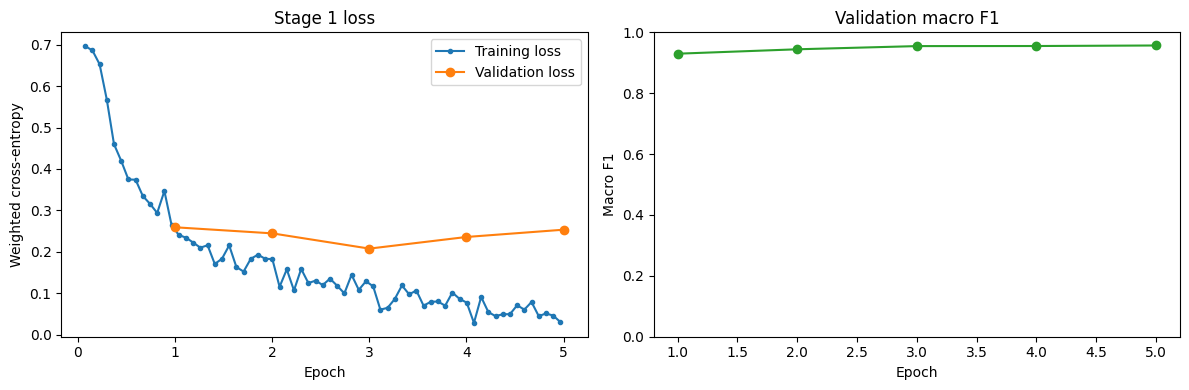

Saved figure to /content/drive/MyDrive/bangla-news-framing/artifacts/figures/stage1_training_history.png


In [ ]:
# Cell 35
stage1_history = pd.DataFrame(
    relevance_trainer.state.log_history
)

display(stage1_history)

training_logs = stage1_history[
    stage1_history["loss"].notna()
].copy()

evaluation_logs = stage1_history[
    stage1_history["eval_loss"].notna()
].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

if not training_logs.empty:
    axes[0].plot(
        training_logs["epoch"],
        training_logs["loss"],
        marker=".",
        label="Training loss",
    )

if not evaluation_logs.empty:
    axes[0].plot(
        evaluation_logs["epoch"],
        evaluation_logs["eval_loss"],
        marker="o",
        label="Validation loss",
    )

axes[0].set_title("Stage 1 loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted cross-entropy")
axes[0].legend()

if not evaluation_logs.empty:
    axes[1].plot(
        evaluation_logs["epoch"],
        evaluation_logs["eval_macro_f1"],
        marker="o",
        color="tab:green",
    )

axes[1].set_title("Validation macro F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1)

plt.tight_layout()

stage1_history_path = (
    FIGURES_DIR / "stage1_training_history.png"
)
plt.savefig(
    stage1_history_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"Saved figure to {stage1_history_path}")

Stage 1 validation metrics


,value
threshold,0.500000
accuracy,0.970738
macro_f1,0.956787
nr_precision,0.979592
nr_recall,0.983095
nr_f1,0.981340
nr_support,3076.000000
relevant_precision,0.938316
relevant_recall,0.926230
relevant_f1,0.932233


Validation NR-majority baseline


,value
threshold,0.500000
accuracy,0.782697
macro_f1,0.439052
nr_precision,0.782697
nr_recall,1.000000
nr_f1,0.878104
nr_support,3076.000000
relevant_precision,0.000000
relevant_recall,0.000000
relevant_f1,0.000000


Validation classification report


,precision,recall,f1-score,support
NR,0.979592,0.983095,0.981340,3076.000000
RELEVANT,0.938316,0.926230,0.932233,854.000000
accuracy,0.970738,0.970738,0.970738,0.970738
macro avg,0.958954,0.954662,0.956787,3930.000000
weighted avg,0.970622,0.970738,0.970669,3930.000000


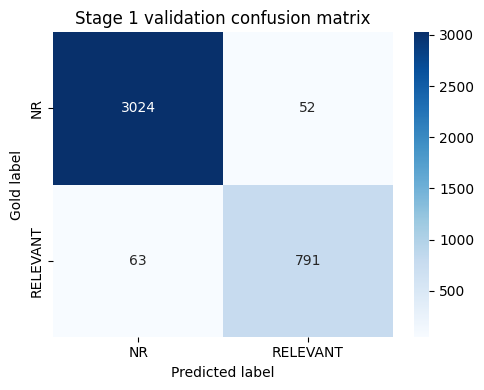

Relevance threshold frozen at 0.5


In [ ]:
# Cell 36
RELEVANCE_THRESHOLD = 0.5


def binary_metrics_from_scores(
    gold_labels,
    relevant_probabilities,
    threshold=0.5,
):
    gold_labels = np.asarray(
        gold_labels,
        dtype=int,
    )
    relevant_probabilities = np.asarray(
        relevant_probabilities,
        dtype=float,
    )
    predicted_labels = (
        relevant_probabilities >= threshold
    ).astype(int)

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            gold_labels,
            predicted_labels,
            labels=[0, 1],
            zero_division=0,
        )
    )

    return {
        "threshold": float(threshold),
        "accuracy": float(
            accuracy_score(
                gold_labels,
                predicted_labels,
            )
        ),
        "macro_f1": float(
            f1_score(
                gold_labels,
                predicted_labels,
                average="macro",
                zero_division=0,
            )
        ),
        "nr_precision": float(precision[0]),
        "nr_recall": float(recall[0]),
        "nr_f1": float(f1[0]),
        "nr_support": int(support[0]),
        "relevant_precision": float(precision[1]),
        "relevant_recall": float(recall[1]),
        "relevant_f1": float(f1[1]),
        "relevant_support": int(support[1]),
        "relevant_pr_auc": float(
            average_precision_score(
                gold_labels,
                relevant_probabilities,
            )
        ),
    }


def plot_relevance_confusion_matrix(
    gold_labels,
    predicted_labels,
    title,
    output_path,
):
    matrix = confusion_matrix(
        gold_labels,
        predicted_labels,
        labels=[0, 1],
    )

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["NR", "RELEVANT"],
        yticklabels=["NR", "RELEVANT"],
    )
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("Gold label")
    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


validation_output = relevance_trainer.predict(
    validation_relevance_dataset,
    metric_key_prefix="validation",
)

validation_logits = validation_output.predictions
if isinstance(validation_logits, tuple):
    validation_logits = validation_logits[0]

validation_probabilities = numpy_softmax(
    validation_logits
)
validation_relevant_probability = (
    validation_probabilities[:, 1]
)
validation_gold = (
    validation_relevance_frame["labels"]
    .to_numpy(dtype=int)
)
validation_predicted = (
    validation_relevant_probability
    >= RELEVANCE_THRESHOLD
).astype(int)

validation_metrics = binary_metrics_from_scores(
    validation_gold,
    validation_relevant_probability,
    RELEVANCE_THRESHOLD,
)

# Majority baseline: predict NR for every pair.
validation_baseline_metrics = (
    binary_metrics_from_scores(
        validation_gold,
        np.zeros_like(
            validation_gold,
            dtype=float,
        ),
        RELEVANCE_THRESHOLD,
    )
)

print("Stage 1 validation metrics")
display(
    pd.Series(
        validation_metrics,
        name="value",
    ).to_frame()
)

print("Validation NR-majority baseline")
display(
    pd.Series(
        validation_baseline_metrics,
        name="value",
    ).to_frame()
)

print("Validation classification report")
validation_report = classification_report(
    validation_gold,
    validation_predicted,
    labels=[0, 1],
    target_names=["NR", "RELEVANT"],
    output_dict=True,
    zero_division=0,
)
display(
    pd.DataFrame(validation_report).T
)

plot_relevance_confusion_matrix(
    validation_gold,
    validation_predicted,
    "Stage 1 validation confusion matrix",
    FIGURES_DIR / "stage1_validation_confusion_matrix.png",
)

validation_predictions = (
    validation_relevance_frame[
        [
            "article_id",
            "event_name",
            "sentence_id",
            "sentence_section",
            "aspect_id",
            "aspect_column",
            "aspect_text",
            "aspect_label",
            "is_quote",
            "stance_holder",
            "token_length",
        ]
    ]
    .copy()
)

validation_predictions["gold_relevance_id"] = (
    validation_gold
)
validation_predictions["gold_relevance_label"] = [
    RELEVANCE_ID2LABEL[label]
    for label in validation_gold
]
validation_predictions["probability_nr"] = (
    validation_probabilities[:, 0]
)
validation_predictions["probability_relevant"] = (
    validation_relevant_probability
)
validation_predictions["predicted_relevance_id"] = (
    validation_predicted
)
validation_predictions["predicted_relevance_label"] = [
    RELEVANCE_ID2LABEL[label]
    for label in validation_predicted
]

validation_predictions.to_csv(
    OUTPUT_DIR / "relevance_validation_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

threshold_record = {
    "threshold": RELEVANCE_THRESHOLD,
    "selection_policy": (
        "Fixed initial threshold; no threshold tuning performed"
    ),
    "selection_split": "validation",
    "test_metrics_seen_at_selection_time": False,
}

with (
    OUTPUT_DIR / "relevance_threshold.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        threshold_record,
        file,
        ensure_ascii=False,
        indent=2,
    )

print(
    "Relevance threshold frozen at",
    RELEVANCE_THRESHOLD,
)

**Cell 37**

## 11. Stage 1 final test evaluation

Training, early stopping, best-checkpoint selection, and the relevance threshold
are now frozen. The test split can therefore be evaluated once.

The majority baseline predicts `NR` for every pair. Because the dataset is
imbalanced, model quality is judged primarily by macro F1, relevant-class
recall/F1, PR-AUC, and the confusion matrix—not accuracy alone.

Tokenizing relevance test pairs:   0%|          | 0/6348 [00:00<?, ? examples/s]

Test events:   4
Test articles: 18
Test pairs:    6,348
Event and article leakage checks: PASSED



Stage 1 test metrics


,value
threshold,0.500000
accuracy,0.963138
macro_f1,0.945748
nr_precision,0.972940
nr_recall,0.980012
nr_f1,0.976463
nr_support,4953.000000
relevant_precision,0.927152
relevant_recall,0.903226
relevant_f1,0.915033


Test NR-majority baseline


,value
threshold,0.500000
accuracy,0.780246
macro_f1,0.438280
nr_precision,0.780246
nr_recall,1.000000
nr_f1,0.876560
nr_support,4953.000000
relevant_precision,0.000000
relevant_recall,0.000000
relevant_f1,0.000000


Test classification report


,precision,recall,f1-score,support
NR,0.972940,0.980012,0.976463,4953.000000
RELEVANT,0.927152,0.903226,0.915033,1395.000000
accuracy,0.963138,0.963138,0.963138,0.963138
macro avg,0.950046,0.941619,0.945748,6348.000000
weighted avg,0.962878,0.963138,0.962964,6348.000000


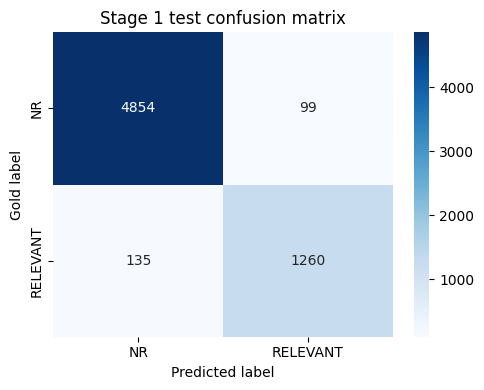


Saved Stage 1 artifacts:
/content/drive/MyDrive/bangla-news-framing/artifacts/relevance_metrics.json
/content/drive/MyDrive/bangla-news-framing/artifacts/relevance_test_predictions.csv
/content/drive/MyDrive/bangla-news-framing/artifacts/figures/stage1_test_confusion_matrix.png


In [ ]:
# Cell 38
# Stage 1 one-time evaluation on the untouched test split

assert "relevance_trainer" in globals(), (
    "The trained relevance model is not in runtime memory. "
    "Reload the saved relevance_model before testing."
)
assert RELEVANCE_THRESHOLD == 0.5, (
    "The frozen relevance threshold must remain 0.5."
)

test_relevance_frame = prepare_relevance_frame(
    long_df,
    "test",
)

test_relevance_dataset = make_relevance_dataset(
    test_relevance_frame,
    "Tokenizing relevance test pairs",
)

# Final leakage checks before viewing test performance.
train_events_stage1 = set(
    train_relevance_frame["event_name"]
)
validation_events_stage1 = set(
    validation_relevance_frame["event_name"]
)
test_events_stage1 = set(
    test_relevance_frame["event_name"]
)

assert train_events_stage1.isdisjoint(
    validation_events_stage1
)
assert train_events_stage1.isdisjoint(
    test_events_stage1
)
assert validation_events_stage1.isdisjoint(
    test_events_stage1
)

train_articles_stage1 = set(
    train_relevance_frame["article_id"]
)
validation_articles_stage1 = set(
    validation_relevance_frame["article_id"]
)
test_articles_stage1 = set(
    test_relevance_frame["article_id"]
)

assert train_articles_stage1.isdisjoint(
    validation_articles_stage1
)
assert train_articles_stage1.isdisjoint(
    test_articles_stage1
)
assert validation_articles_stage1.isdisjoint(
    test_articles_stage1
)

print(f"Test events:   {len(test_events_stage1)}")
print(f"Test articles: {len(test_articles_stage1)}")
print(f"Test pairs:    {len(test_relevance_frame):,}")
print("Event and article leakage checks: PASSED")

# This is the first model evaluation on the test split.
test_output = relevance_trainer.predict(
    test_relevance_dataset,
    metric_key_prefix="test",
)

test_logits = test_output.predictions

if isinstance(test_logits, tuple):
    test_logits = test_logits[0]

test_probabilities = numpy_softmax(
    test_logits
)

test_relevant_probability = (
    test_probabilities[:, 1]
)

test_gold = (
    test_relevance_frame["labels"]
    .to_numpy(dtype=int)
)

test_predicted = (
    test_relevant_probability
    >= RELEVANCE_THRESHOLD
).astype(int)

test_metrics = binary_metrics_from_scores(
    test_gold,
    test_relevant_probability,
    RELEVANCE_THRESHOLD,
)

# NR-majority baseline for the same test examples.
test_baseline_metrics = binary_metrics_from_scores(
    test_gold,
    np.zeros_like(
        test_gold,
        dtype=float,
    ),
    RELEVANCE_THRESHOLD,
)

print("\nStage 1 test metrics")
display(
    pd.Series(
        test_metrics,
        name="value",
    ).to_frame()
)

print("Test NR-majority baseline")
display(
    pd.Series(
        test_baseline_metrics,
        name="value",
    ).to_frame()
)

print("Test classification report")

test_report = classification_report(
    test_gold,
    test_predicted,
    labels=[0, 1],
    target_names=["NR", "RELEVANT"],
    output_dict=True,
    zero_division=0,
)

display(
    pd.DataFrame(test_report).T
)

plot_relevance_confusion_matrix(
    test_gold,
    test_predicted,
    "Stage 1 test confusion matrix",
    (
        FIGURES_DIR
        / "stage1_test_confusion_matrix.png"
    ),
)

# Retain metadata for error analysis and the later full pipeline.
test_predictions = (
    test_relevance_frame[
        [
            "article_id",
            "event_name",
            "sentence_id",
            "sentence_index",
            "sentence_section",
            "sentence_text_raw",
            "sentence_text_clean",
            "aspect_id",
            "aspect_column",
            "aspect_text",
            "aspect_label",
            "is_quote",
            "stance_holder",
            "token_length",
        ]
    ]
    .copy()
)

test_predictions["gold_relevance_id"] = (
    test_gold
)
test_predictions["gold_relevance_label"] = [
    RELEVANCE_ID2LABEL[label]
    for label in test_gold
]
test_predictions["probability_nr"] = (
    test_probabilities[:, 0]
)
test_predictions["probability_relevant"] = (
    test_relevant_probability
)
test_predictions["predicted_relevance_id"] = (
    test_predicted
)
test_predictions["predicted_relevance_label"] = [
    RELEVANCE_ID2LABEL[label]
    for label in test_predicted
]

test_predictions["is_correct"] = (
    test_predictions["gold_relevance_id"]
    == test_predictions["predicted_relevance_id"]
)

test_predictions.to_csv(
    OUTPUT_DIR / "relevance_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

relevance_metrics_artifact = {
    "model_name": CONFIG["model_name"],
    "selection_metric": "validation macro F1",
    "best_checkpoint": (
        relevance_trainer.state.best_model_checkpoint
    ),
    "best_validation_metric_during_training": float(
        relevance_trainer.state.best_metric
    ),
    "completed_epoch": float(
        relevance_trainer.state.epoch
    ),
    "threshold": RELEVANCE_THRESHOLD,
    "threshold_policy": (
        "Fixed at 0.5; not tuned using test data"
    ),
    "training_class_counts": {
        "NR": int(train_class_counts.loc[0]),
        "RELEVANT": int(train_class_counts.loc[1]),
    },
    "training_class_weights": {
        "NR": float(relevance_class_weights[0]),
        "RELEVANT": float(relevance_class_weights[1]),
    },
    "validation": validation_metrics,
    "validation_majority_baseline": (
        validation_baseline_metrics
    ),
    "test": test_metrics,
    "test_majority_baseline": (
        test_baseline_metrics
    ),
    "annotation_status": (
        "AI-assisted annotations; not a fully "
        "human-verified gold standard"
    ),
}

with (
    OUTPUT_DIR / "relevance_metrics.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        relevance_metrics_artifact,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("\nSaved Stage 1 artifacts:")
print(
    OUTPUT_DIR / "relevance_metrics.json"
)
print(
    OUTPUT_DIR / "relevance_test_predictions.csv"
)
print(
    FIGURES_DIR
    / "stage1_test_confusion_matrix.png"
)

**Cell 39**

## 12. Stage 2: government-directed stance classification

Stage 2 is trained only on **gold-relevant training pairs** where the original
aspect label is not `NR`.

The three output classes are:

- `N`: relevant but neutral or descriptive toward the government's role
- `GF`: favourable toward the government's role or performance
- `GC`: critical toward the government's role or performance

This is not general positive/negative sentiment classification. The target is
the expressed stance toward the government's role in the specified aspect.

The same target-aware input is used:

```text
cleaned Bangla sentence + complete Bangla aspect description

In [ ]:
# Cell 40

### Cell 2 — Release Stage 1 GPU memory and prepare stance data

import gc

# Stage 1 is already saved to Drive. Release its GPU memory before
# loading a separate BanglaBERT model for Stage 2.
globals().pop("relevance_trainer", None)
globals().pop("test_output", None)
globals().pop("validation_output", None)

gc.collect()
torch.cuda.empty_cache()

print(
    "Allocated GPU memory after Stage 1 cleanup:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB",
)

STANCE_ID2LABEL = {
    value: key
    for key, value in STANCE_LABEL2ID.items()
}
STANCE_LABEL_ORDER = ["N", "GF", "GC"]
STANCE_ID_ORDER = [0, 1, 2]

STANCE_RUN_DIR = (
    OUTPUT_DIR / "stance_training_checkpoints"
)
STANCE_MODEL_DIR = (
    OUTPUT_DIR / "stance_model"
)

STANCE_RUN_DIR.mkdir(
    parents=True,
    exist_ok=True,
)
STANCE_MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


def prepare_stance_frame(
    pair_frame: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:
    """
    Select only gold-relevant pairs for one event-grouped split.
    """
    frame = (
        pair_frame.loc[
            pair_frame["split"].eq(split_name)
            & pair_frame["aspect_label"].ne("NR")
        ]
        .copy()
        .reset_index(drop=True)
    )

    frame["labels"] = (
        frame["stance_label"]
        .map(STANCE_LABEL2ID)
        .astype("int64")
    )

    assert not frame.empty
    assert frame["stance_label"].notna().all()
    assert set(frame["stance_label"].unique()) == {
        "N",
        "GF",
        "GC",
    }
    assert set(frame["labels"].unique()) == {0, 1, 2}
    assert frame["sentence_text_clean"].str.strip().ne("").all()
    assert frame["aspect_text"].str.strip().ne("").all()

    return frame


train_stance_frame = prepare_stance_frame(
    long_df,
    "train",
)
validation_stance_frame = prepare_stance_frame(
    long_df,
    "validation",
)

assert set(train_stance_frame["event_name"]).isdisjoint(
    set(validation_stance_frame["event_name"])
)

train_stance_counts = (
    train_stance_frame["labels"]
    .value_counts()
    .reindex(STANCE_ID_ORDER)
    .astype(int)
)

# Moderate weighting:
# raw_weight_c = 1 / sqrt(training frequency of class c)
#
# Normalizing the mean weight to 1 does not alter relative weighting,
# but makes the values easier to interpret.
raw_inverse_sqrt_weights = (
    1.0
    / np.sqrt(
        train_stance_counts.to_numpy(
            dtype=np.float64
        )
    )
)

stance_class_weights = (
    raw_inverse_sqrt_weights
    / raw_inverse_sqrt_weights.mean()
).astype(np.float32)

stance_weight_table = pd.DataFrame(
    {
        "label_id": STANCE_ID_ORDER,
        "label": STANCE_LABEL_ORDER,
        "training_count": train_stance_counts.values,
        "inverse_sqrt_weight": stance_class_weights,
    }
)

print(
    f"Gold-relevant training pairs: "
    f"{len(train_stance_frame):,}"
)
print(
    f"Gold-relevant validation pairs: "
    f"{len(validation_stance_frame):,}"
)
display(stance_weight_table)

print("Training stance proportions")
display(
    train_stance_frame["stance_label"]
    .value_counts(normalize=True)
    .reindex(STANCE_LABEL_ORDER)
    .mul(100)
    .round(2)
    .rename("percent")
    .to_frame()
)

assert np.isfinite(stance_class_weights).all()
assert (stance_class_weights > 0).all()

Allocated GPU memory after Stage 1 cleanup: 0.02 GB
Gold-relevant training pairs: 4,969
Gold-relevant validation pairs: 854


,label_id,label,training_count,inverse_sqrt_weight
0,0,N,4747,0.201246
1,1,GF,68,1.681440
2,2,GC,154,1.117315


Training stance proportions


,percent
stance_label,
N,95.53
GF,1.37
GC,3.10


In [ ]:
# Cell 41
def tokenize_stance_batch(examples):
    """
    Tokenize the sentence and aspect as a paired input.

    Padding is deferred to the dynamic data collator.
    """
    encoded = tokenizer(
        examples["sentence_text_clean"],
        examples["aspect_text"],
        truncation=True,
        max_length=CONFIG["max_length"],
        padding=False,
    )
    encoded["labels"] = examples["labels"]

    return encoded


def make_stance_dataset(
    frame: pd.DataFrame,
    description: str,
) -> Dataset:
    model_frame = frame[
        [
            "sentence_text_clean",
            "aspect_text",
            "labels",
        ]
    ].copy()

    dataset = Dataset.from_pandas(
        model_frame,
        preserve_index=False,
    )

    return dataset.map(
        tokenize_stance_batch,
        batched=True,
        remove_columns=dataset.column_names,
        desc=description,
    )


train_stance_dataset = make_stance_dataset(
    train_stance_frame,
    "Tokenizing stance training pairs",
)
validation_stance_dataset = make_stance_dataset(
    validation_stance_frame,
    "Tokenizing stance validation pairs",
)

stance_data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",
    pad_to_multiple_of=8,
    return_tensors="pt",
)

stance_sample_batch = stance_data_collator(
    [
        train_stance_dataset[0],
        train_stance_dataset[1],
    ]
)

print("Example Stage 2 batch dimensions")
for key, value in stance_sample_batch.items():
    print(f"  {key}: {tuple(value.shape)}")

Tokenizing stance training pairs:   0%|          | 0/4969 [00:00<?, ? examples/s]

Tokenizing stance validation pairs:   0%|          | 0/854 [00:00<?, ? examples/s]

Example Stage 2 batch dimensions
  labels: (2,)
  input_ids: (2, 64)
  token_type_ids: (2, 64)
  attention_mask: (2, 64)


In [ ]:
# Cell 42
def stance_metrics_from_predictions(
    gold_labels,
    predicted_labels,
):
    """Calculate multiclass stance metrics."""
    gold_labels = np.asarray(
        gold_labels,
        dtype=int,
    )
    predicted_labels = np.asarray(
        predicted_labels,
        dtype=int,
    )

    precision, recall, f1, support = (
        precision_recall_fscore_support(
            gold_labels,
            predicted_labels,
            labels=STANCE_ID_ORDER,
            zero_division=0,
        )
    )

    metrics = {
        "accuracy": float(
            accuracy_score(
                gold_labels,
                predicted_labels,
            )
        ),
        "macro_f1": float(
            f1_score(
                gold_labels,
                predicted_labels,
                labels=STANCE_ID_ORDER,
                average="macro",
                zero_division=0,
            )
        ),
    }

    for index, label_name in enumerate(
        STANCE_LABEL_ORDER
    ):
        prefix = label_name.lower()

        metrics[f"{prefix}_precision"] = float(
            precision[index]
        )
        metrics[f"{prefix}_recall"] = float(
            recall[index]
        )
        metrics[f"{prefix}_f1"] = float(
            f1[index]
        )
        metrics[f"{prefix}_support"] = int(
            support[index]
        )

    return metrics


def compute_stance_metrics(eval_prediction):
    logits = eval_prediction.predictions

    if isinstance(logits, tuple):
        logits = logits[0]

    predicted_labels = np.asarray(
        logits
    ).argmax(axis=1)

    return stance_metrics_from_predictions(
        eval_prediction.label_ids,
        predicted_labels,
    )


def stance_model_init():
    """
    Initialize an independent BanglaBERT stance classifier.

    The classification head maps a 768-dimensional contextual
    representation to three stance logits.
    """
    return AutoModelForSequenceClassification.from_pretrained(
        CONFIG["model_name"],
        num_labels=3,
        id2label=STANCE_ID2LABEL,
        label2id=STANCE_LABEL2ID,
    )


stance_gradient_accumulation_steps = 1

stance_effective_batch_size = (
    CONFIG["train_batch_size"]
    * stance_gradient_accumulation_steps
    * max(torch.cuda.device_count(), 1)
)

stance_steps_per_epoch = math.ceil(
    len(train_stance_dataset)
    / stance_effective_batch_size
)

stance_maximum_steps = math.ceil(
    stance_steps_per_epoch
    * CONFIG["max_epochs"]
)

stance_warmup_steps = math.ceil(
    CONFIG["warmup_ratio"]
    * stance_maximum_steps
)

print(
    "Stage 2 effective batch size:",
    stance_effective_batch_size,
)
print(
    "Stage 2 steps per epoch:",
    stance_steps_per_epoch,
)
print(
    "Stage 2 maximum steps:",
    stance_maximum_steps,
)
print(
    "Stage 2 warmup steps:",
    stance_warmup_steps,
)

stance_argument_parameters = inspect.signature(
    TrainingArguments.__init__
).parameters

stance_argument_values = {
    "output_dir": str(STANCE_RUN_DIR),
    "learning_rate": CONFIG["learning_rate"],
    "per_device_train_batch_size": (
        CONFIG["train_batch_size"]
    ),
    "per_device_eval_batch_size": (
        CONFIG["eval_batch_size"]
    ),
    "gradient_accumulation_steps": (
        stance_gradient_accumulation_steps
    ),
    "num_train_epochs": CONFIG["max_epochs"],
    "weight_decay": CONFIG["weight_decay"],
    "warmup_steps": stance_warmup_steps,
    "logging_strategy": "steps",
    "logging_steps": 50,
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "macro_f1",
    "greater_is_better": True,
    "save_total_limit": 2,
    "fp16": use_fp16,
    "bf16": use_bf16,
    "seed": SEED,
    "data_seed": SEED,
    "dataloader_num_workers": 2,
    "dataloader_pin_memory": True,
    "report_to": "none",
    "push_to_hub": False,
    "optim": "adamw_torch",
    "run_name": "banglabert-stage2-stance",
}

optional_stance_arguments = {
    "save_safetensors": True,
    "restore_callback_states_from_checkpoint": True,
}

for argument_name, argument_value in (
    optional_stance_arguments.items()
):
    if argument_name in stance_argument_parameters:
        stance_argument_values[
            argument_name
        ] = argument_value

if "eval_strategy" in stance_argument_parameters:
    stance_argument_values["eval_strategy"] = "epoch"
elif (
    "evaluation_strategy"
    in stance_argument_parameters
):
    stance_argument_values[
        "evaluation_strategy"
    ] = "epoch"
else:
    raise RuntimeError(
        "No supported evaluation-strategy argument found."
    )

unsupported_stance_arguments = sorted(
    set(stance_argument_values)
    - set(stance_argument_parameters)
)

if unsupported_stance_arguments:
    print(
        "Unsupported optional arguments omitted:",
        unsupported_stance_arguments,
    )

stance_argument_values = {
    name: value
    for name, value in stance_argument_values.items()
    if name in stance_argument_parameters
}

stance_training_args = TrainingArguments(
    **stance_argument_values
)

stance_trainer_arguments = {
    "model_init": stance_model_init,
    "args": stance_training_args,
    "train_dataset": train_stance_dataset,
    "eval_dataset": validation_stance_dataset,
    "data_collator": stance_data_collator,
    "compute_metrics": compute_stance_metrics,
    "callbacks": [
        EarlyStoppingCallback(
            early_stopping_patience=(
                CONFIG["early_stopping_patience"]
            ),
            early_stopping_threshold=0.0,
        )
    ],
    "class_weights": stance_class_weights,
}

if "processing_class" in trainer_init_parameters:
    stance_trainer_arguments[
        "processing_class"
    ] = tokenizer
elif "tokenizer" in trainer_init_parameters:
    stance_trainer_arguments[
        "tokenizer"
    ] = tokenizer

stance_trainer = WeightedClassificationTrainer(
    **stance_trainer_arguments
)

stance_total_parameters = sum(
    parameter.numel()
    for parameter in stance_trainer.model.parameters()
)
stance_trainable_parameters = sum(
    parameter.numel()
    for parameter in stance_trainer.model.parameters()
    if parameter.requires_grad
)

print(
    "Stage 2 total parameters:",
    f"{stance_total_parameters:,}",
)
print(
    "Stage 2 trainable parameters:",
    f"{stance_trainable_parameters:,}",
)
print(
    "Stage 2 classifier output dimension:",
    stance_trainer.model.config.num_labels,
)

Stage 2 effective batch size: 16
Stage 2 steps per epoch: 311
Stage 2 maximum steps: 1555
Stage 2 warmup steps: 156


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Stage 2 total parameters: 110,619,651
Stage 2 trainable parameters: 110,619,651
Stage 2 classifier output dimension: 3


In [ ]:
# Cell 43
# First Stage 2 run: False
# Continue an interrupted Stage 2 run: True
RESUME_STAGE2 = False

last_stance_checkpoint = None

if STANCE_RUN_DIR.exists():
    last_stance_checkpoint = get_last_checkpoint(
        str(STANCE_RUN_DIR)
    )

if RESUME_STAGE2:
    if last_stance_checkpoint is None:
        raise FileNotFoundError(
            "RESUME_STAGE2=True, but no Stage 2 "
            "checkpoint was found."
        )

    stance_resume_checkpoint = (
        last_stance_checkpoint
    )

    print(
        "Resuming Stage 2 from:",
        stance_resume_checkpoint,
    )
else:
    stance_resume_checkpoint = None

    if last_stance_checkpoint is not None:
        print(
            "An existing Stage 2 checkpoint was found:",
            last_stance_checkpoint,
        )
        print(
            "It is not being used because "
            "RESUME_STAGE2=False."
        )

    print(
        "Starting Stage 2 from pretrained BanglaBERT."
    )

stance_train_result = stance_trainer.train(
    resume_from_checkpoint=stance_resume_checkpoint
)

stance_trainer.save_model(
    str(STANCE_MODEL_DIR)
)
tokenizer.save_pretrained(
    str(STANCE_MODEL_DIR)
)
stance_trainer.save_state()
stance_trainer.save_metrics(
    "train",
    stance_train_result.metrics,
)

print("Stage 2 training completed.")
print(
    "Best checkpoint:",
    stance_trainer.state.best_model_checkpoint,
)
print(
    "Best validation macro F1:",
    stance_trainer.state.best_metric,
)
print(
    "Completed epoch:",
    stance_trainer.state.epoch,
)
print(
    "Final model saved to:",
    STANCE_MODEL_DIR,
)

Starting Stage 2 from pretrained BanglaBERT.


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,N Precision,N Recall,N F1,N Support,Gf Precision,Gf Recall,Gf F1,Gf Support,Gc Precision,Gc Recall,Gc F1,Gc Support
1,0.433948,0.571256,0.960187,0.326563,0.961313,0.998782,0.979689,821,0.000000,0.000000,0.000000,9,0.000000,0.000000,0.000000,24
2,0.240523,0.715354,0.957845,0.390647,0.964497,0.992692,0.978391,821,0.000000,0.000000,0.000000,9,0.428571,0.125000,0.193548,24
3,0.174037,0.822924,0.962529,0.376336,0.963572,0.998782,0.980861,821,0.000000,0.000000,0.000000,9,0.666667,0.083333,0.148148,24
4,0.058718,0.870126,0.959016,0.390851,0.964539,0.993910,0.979004,821,0.000000,0.000000,0.000000,9,0.428571,0.125000,0.193548,24
5,0.004268,0.893323,0.963700,0.398578,0.964706,0.998782,0.981448,821,0.000000,0.000000,0.000000,9,0.750000,0.125000,0.214286,24


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Stage 2 training completed.
Best checkpoint: /content/drive/MyDrive/bangla-news-framing/artifacts/stance_training_checkpoints/checkpoint-1555
Best validation macro F1: 0.39857798295859337
Completed epoch: 5.0
Final model saved to: /content/drive/MyDrive/bangla-news-framing/artifacts/stance_model


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_macro_f1,eval_n_precision,eval_n_recall,...,eval_gc_f1,eval_gc_support,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.986821,3.124659,6.282051e-06,0.160772,50,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.677621,2.318943,1.269231e-05,0.321543,100,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.683963,5.835717,1.910256e-05,0.482315,150,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.505138,0.833966,1.938528e-05,0.643087,200,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.580812,1.424250,1.867048e-05,0.803859,250,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,0.433948,2.756193,1.795568e-05,0.964630,300,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,1.000000,311,0.571256,0.960187,0.326563,0.961313,0.998782,...,0.000000,24.0,5.2940,161.316,5.100,NaN,NaN,NaN,NaN,NaN
7,0.344466,1.243941,1.724089e-05,1.125402,350,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,0.398734,0.211281,1.652609e-05,1.286174,400,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0.305581,0.187449,1.581129e-05,1.446945,450,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


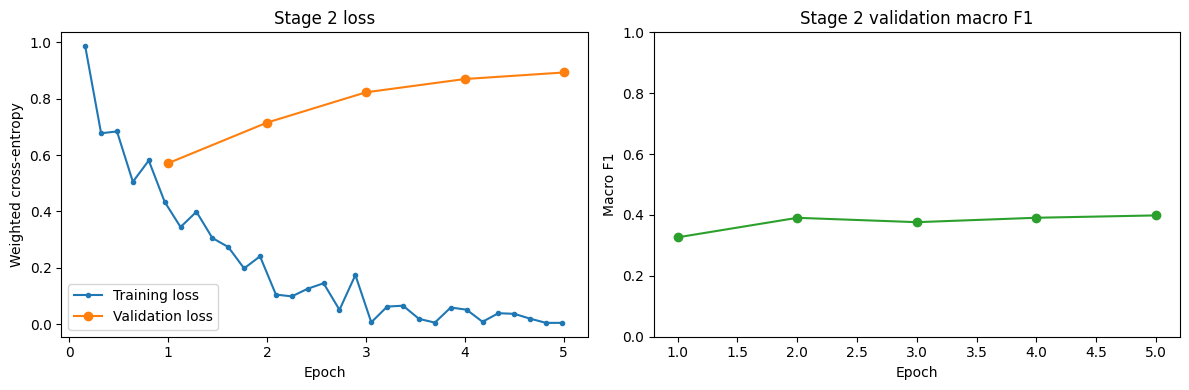

Saved figure to /content/drive/MyDrive/bangla-news-framing/artifacts/figures/stage2_training_history.png


In [ ]:
# Cell 44
stage2_history = pd.DataFrame(
    stance_trainer.state.log_history
)

display(stage2_history)

stage2_training_logs = stage2_history[
    stage2_history["loss"].notna()
].copy()

stage2_evaluation_logs = stage2_history[
    stage2_history["eval_loss"].notna()
].copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4),
)

if not stage2_training_logs.empty:
    axes[0].plot(
        stage2_training_logs["epoch"],
        stage2_training_logs["loss"],
        marker=".",
        label="Training loss",
    )

if not stage2_evaluation_logs.empty:
    axes[0].plot(
        stage2_evaluation_logs["epoch"],
        stage2_evaluation_logs["eval_loss"],
        marker="o",
        label="Validation loss",
    )

axes[0].set_title("Stage 2 loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Weighted cross-entropy")
axes[0].legend()

if not stage2_evaluation_logs.empty:
    axes[1].plot(
        stage2_evaluation_logs["epoch"],
        stage2_evaluation_logs["eval_macro_f1"],
        marker="o",
        color="tab:green",
    )

axes[1].set_title("Stage 2 validation macro F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Macro F1")
axes[1].set_ylim(0, 1)

plt.tight_layout()

stage2_history_path = (
    FIGURES_DIR / "stage2_training_history.png"
)

plt.savefig(
    stage2_history_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print(f"Saved figure to {stage2_history_path}")

Stage 2 gold-relevant validation metrics


,value
accuracy,0.963700
macro_f1,0.398578
n_precision,0.964706
n_recall,0.998782
n_f1,0.981448
n_support,821.000000
gf_precision,0.000000
gf_recall,0.000000
gf_f1,0.000000
gf_support,9.000000


Validation neutral-majority baseline


,value
accuracy,0.961358
macro_f1,0.326766
n_precision,0.961358
n_recall,1.000000
n_f1,0.980299
n_support,821.000000
gf_precision,0.000000
gf_recall,0.000000
gf_f1,0.000000
gf_support,9.000000


,precision,recall,f1-score,support
N,0.964706,0.998782,0.981448,821.0000
GF,0.000000,0.000000,0.000000,9.0000
GC,0.750000,0.125000,0.214286,24.0000
accuracy,0.963700,0.963700,0.963700,0.9637
macro avg,0.571569,0.374594,0.398578,854.0000
weighted avg,0.948505,0.963700,0.949546,854.0000


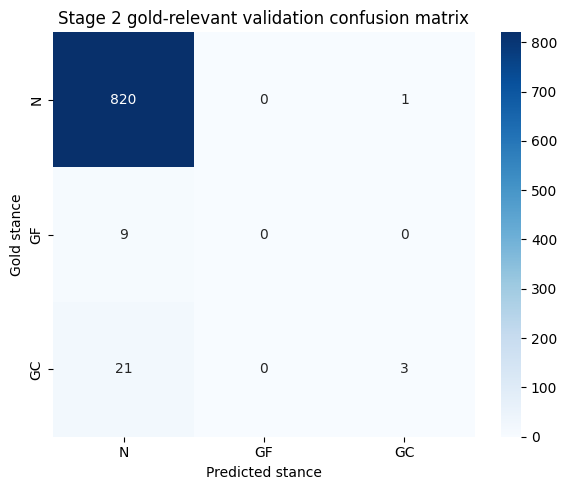

In [ ]:
# Cell 45
def plot_stance_confusion_matrix(
    gold_labels,
    predicted_labels,
    title,
    output_path,
):
    matrix = confusion_matrix(
        gold_labels,
        predicted_labels,
        labels=STANCE_ID_ORDER,
    )

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=STANCE_LABEL_ORDER,
        yticklabels=STANCE_LABEL_ORDER,
    )
    plt.title(title)
    plt.xlabel("Predicted stance")
    plt.ylabel("Gold stance")
    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()


validation_stance_output = stance_trainer.predict(
    validation_stance_dataset,
    metric_key_prefix="validation_stance",
)

validation_stance_logits = (
    validation_stance_output.predictions
)

if isinstance(validation_stance_logits, tuple):
    validation_stance_logits = (
        validation_stance_logits[0]
    )

validation_stance_probabilities = (
    numpy_softmax(validation_stance_logits)
)
validation_stance_gold = (
    validation_stance_frame["labels"]
    .to_numpy(dtype=int)
)
validation_stance_predicted = (
    validation_stance_probabilities.argmax(
        axis=1
    )
)

validation_stance_metrics = (
    stance_metrics_from_predictions(
        validation_stance_gold,
        validation_stance_predicted,
    )
)

# Neutral-majority baseline
validation_neutral_baseline = np.zeros_like(
    validation_stance_gold
)

validation_stance_baseline_metrics = (
    stance_metrics_from_predictions(
        validation_stance_gold,
        validation_neutral_baseline,
    )
)

print("Stage 2 gold-relevant validation metrics")
display(
    pd.Series(
        validation_stance_metrics,
        name="value",
    ).to_frame()
)

print("Validation neutral-majority baseline")
display(
    pd.Series(
        validation_stance_baseline_metrics,
        name="value",
    ).to_frame()
)

validation_stance_report = classification_report(
    validation_stance_gold,
    validation_stance_predicted,
    labels=STANCE_ID_ORDER,
    target_names=STANCE_LABEL_ORDER,
    output_dict=True,
    zero_division=0,
)

display(
    pd.DataFrame(validation_stance_report).T
)

plot_stance_confusion_matrix(
    validation_stance_gold,
    validation_stance_predicted,
    "Stage 2 gold-relevant validation confusion matrix",
    FIGURES_DIR / "stage2_validation_confusion_matrix.png",
)

validation_stance_predictions = (
    validation_stance_frame[
        [
            "article_id",
            "event_name",
            "sentence_id",
            "sentence_section",
            "sentence_text_raw",
            "sentence_text_clean",
            "aspect_id",
            "aspect_text",
            "aspect_label",
            "stance_holder",
            "is_quote",
            "token_length",
        ]
    ]
    .copy()
)

validation_stance_predictions["gold_stance_id"] = (
    validation_stance_gold
)
validation_stance_predictions["predicted_stance_id"] = (
    validation_stance_predicted
)
validation_stance_predictions["predicted_stance_label"] = [
    STANCE_ID2LABEL[label]
    for label in validation_stance_predicted
]
validation_stance_predictions["probability_N"] = (
    validation_stance_probabilities[:, 0]
)
validation_stance_predictions["probability_GF"] = (
    validation_stance_probabilities[:, 1]
)
validation_stance_predictions["probability_GC"] = (
    validation_stance_probabilities[:, 2]
)

validation_stance_predictions.to_csv(
    OUTPUT_DIR / "stance_validation_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

**Cell 46**

## 13. Stage 2 gold-relevant test evaluation

The stance model and its best validation checkpoint are now fixed. Evaluation
on gold-relevant test pairs isolates stance-classifier quality from Stage 1
relevance errors.

The test results must be interpreted cautiously because `GF` and `GC` contain
very few examples. High overall accuracy is not evidence of a strong stance
classifier if directional-class recall is zero or near zero.

Tokenizing gold-relevant stance test pairs:   0%|          | 0/1395 [00:00<?, ? examples/s]

Stage 2 gold-relevant test metrics


,value
accuracy,0.934767
macro_f1,0.509823
n_precision,0.955457
n_recall,0.979452
n_f1,0.967306
n_support,1314.000000
gf_precision,0.458333
gf_recall,0.354839
gf_f1,0.400000
gf_support,31.000000


Test neutral-majority baseline


,value
accuracy,0.941935
macro_f1,0.323367
n_precision,0.941935
n_recall,1.000000
n_f1,0.970100
n_support,1314.000000
gf_precision,0.000000
gf_recall,0.000000
gf_f1,0.000000
gf_support,31.000000


,precision,recall,f1-score,support
N,0.955457,0.979452,0.967306,1314.000000
GF,0.458333,0.354839,0.400000,31.000000
GC,0.250000,0.120000,0.162162,50.000000
accuracy,0.934767,0.934767,0.934767,0.934767
macro avg,0.554597,0.484764,0.509823,1395.000000
weighted avg,0.919124,0.934767,0.925841,1395.000000


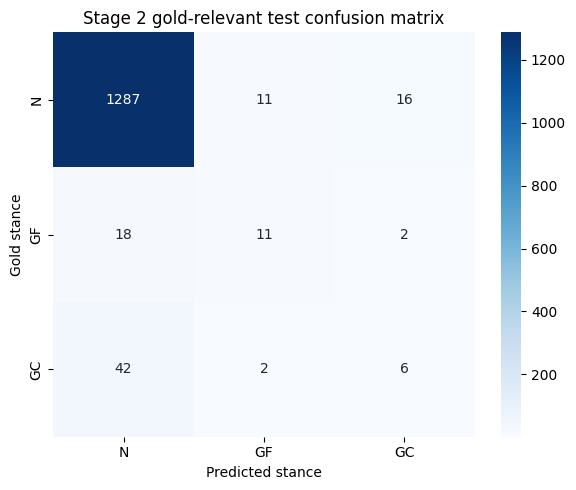


Saved Stage 2 artifacts:
/content/drive/MyDrive/bangla-news-framing/artifacts/stance_model
/content/drive/MyDrive/bangla-news-framing/artifacts/stance_metrics.json
/content/drive/MyDrive/bangla-news-framing/artifacts/stance_test_predictions.csv


In [ ]:
# Cell 47
test_stance_frame = prepare_stance_frame(
    long_df,
    "test",
)
test_stance_dataset = make_stance_dataset(
    test_stance_frame,
    "Tokenizing gold-relevant stance test pairs",
)

assert set(test_stance_frame["event_name"]).isdisjoint(
    set(train_stance_frame["event_name"])
)
assert set(test_stance_frame["event_name"]).isdisjoint(
    set(validation_stance_frame["event_name"])
)

test_stance_output = stance_trainer.predict(
    test_stance_dataset,
    metric_key_prefix="test_stance",
)

test_stance_logits = test_stance_output.predictions

if isinstance(test_stance_logits, tuple):
    test_stance_logits = test_stance_logits[0]

test_stance_probabilities = numpy_softmax(
    test_stance_logits
)
test_stance_gold = (
    test_stance_frame["labels"]
    .to_numpy(dtype=int)
)
test_stance_predicted = (
    test_stance_probabilities.argmax(axis=1)
)

test_stance_metrics = (
    stance_metrics_from_predictions(
        test_stance_gold,
        test_stance_predicted,
    )
)

test_neutral_baseline = np.zeros_like(
    test_stance_gold
)

test_stance_baseline_metrics = (
    stance_metrics_from_predictions(
        test_stance_gold,
        test_neutral_baseline,
    )
)

print("Stage 2 gold-relevant test metrics")
display(
    pd.Series(
        test_stance_metrics,
        name="value",
    ).to_frame()
)

print("Test neutral-majority baseline")
display(
    pd.Series(
        test_stance_baseline_metrics,
        name="value",
    ).to_frame()
)

test_stance_report = classification_report(
    test_stance_gold,
    test_stance_predicted,
    labels=STANCE_ID_ORDER,
    target_names=STANCE_LABEL_ORDER,
    output_dict=True,
    zero_division=0,
)

display(
    pd.DataFrame(test_stance_report).T
)

plot_stance_confusion_matrix(
    test_stance_gold,
    test_stance_predicted,
    "Stage 2 gold-relevant test confusion matrix",
    FIGURES_DIR / "stage2_test_confusion_matrix.png",
)

test_stance_predictions = (
    test_stance_frame[
        [
            "article_id",
            "event_name",
            "sentence_id",
            "sentence_index",
            "sentence_section",
            "sentence_text_raw",
            "sentence_text_clean",
            "aspect_id",
            "aspect_column",
            "aspect_text",
            "aspect_label",
            "stance_holder",
            "is_quote",
            "token_length",
        ]
    ]
    .copy()
)

test_stance_predictions["gold_stance_id"] = (
    test_stance_gold
)
test_stance_predictions["predicted_stance_id"] = (
    test_stance_predicted
)
test_stance_predictions["predicted_stance_label"] = [
    STANCE_ID2LABEL[label]
    for label in test_stance_predicted
]
test_stance_predictions["probability_N"] = (
    test_stance_probabilities[:, 0]
)
test_stance_predictions["probability_GF"] = (
    test_stance_probabilities[:, 1]
)
test_stance_predictions["probability_GC"] = (
    test_stance_probabilities[:, 2]
)
test_stance_predictions["is_correct"] = (
    test_stance_predictions["gold_stance_id"]
    == test_stance_predictions["predicted_stance_id"]
)

test_stance_predictions.to_csv(
    OUTPUT_DIR / "stance_test_predictions.csv",
    index=False,
    encoding="utf-8-sig",
)

stance_metrics_artifact = {
    "model_name": CONFIG["model_name"],
    "evaluation_scope": "gold-relevant pairs only",
    "selection_metric": "validation macro F1",
    "best_checkpoint": (
        stance_trainer.state.best_model_checkpoint
    ),
    "best_validation_metric_during_training": float(
        stance_trainer.state.best_metric
    ),
    "completed_epoch": float(
        stance_trainer.state.epoch
    ),
    "weighting": (
        "inverse square root of training frequency, "
        "normalized to mean 1"
    ),
    "training_class_counts": {
        label: int(
            train_stance_counts.loc[
                STANCE_LABEL2ID[label]
            ]
        )
        for label in STANCE_LABEL_ORDER
    },
    "training_class_weights": {
        label: float(
            stance_class_weights[
                STANCE_LABEL2ID[label]
            ]
        )
        for label in STANCE_LABEL_ORDER
    },
    "validation": validation_stance_metrics,
    "validation_neutral_baseline": (
        validation_stance_baseline_metrics
    ),
    "test": test_stance_metrics,
    "test_neutral_baseline": (
        test_stance_baseline_metrics
    ),
    "annotation_status": (
        "AI-assisted labels with very limited GF and GC "
        "examples; results are preliminary"
    ),
}

with (
    OUTPUT_DIR / "stance_metrics.json"
).open("w", encoding="utf-8") as file:
    json.dump(
        stance_metrics_artifact,
        file,
        ensure_ascii=False,
        indent=2,
    )

directional_recalls = {
    "GF": test_stance_metrics["gf_recall"],
    "GC": test_stance_metrics["gc_recall"],
}

if any(
    recall < 0.10
    for recall in directional_recalls.values()
):
    print(
        "\nWARNING: At least one directional stance class "
        "has recall below 0.10. Do not claim reliable final "
        "stance performance."
    )

print("\nSaved Stage 2 artifacts:")
print(STANCE_MODEL_DIR)
print(
    OUTPUT_DIR / "stance_metrics.json"
)
print(
    OUTPUT_DIR / "stance_test_predictions.csv"
)

In [15]:
# Cell 48
# End-to-end evaluation setup: load paths and reconstruct the untouched test set.

import gc
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
)

RELEVANCE_MODEL_DIR = OUTPUT_DIR / "relevance_model"
STANCE_MODEL_DIR = OUTPUT_DIR / "stance_model"
FIGURES_DIR = OUTPUT_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

assert RELEVANCE_MODEL_DIR.is_dir(), (
    f"Missing Stage 1 model: {RELEVANCE_MODEL_DIR}"
)
assert STANCE_MODEL_DIR.is_dir(), (
    f"Missing Stage 2 model: {STANCE_MODEL_DIR}"
)

def contains_model_weights(model_dir: Path) -> bool:
    """Check for a complete saved Hugging Face model."""
    weight_names = [
        "model.safetensors",
        "pytorch_model.bin",
    ]
    return any(
        (model_dir / filename).is_file()
        for filename in weight_names
    )

assert contains_model_weights(RELEVANCE_MODEL_DIR), (
    "Stage 1 model weights were not found."
)
assert contains_model_weights(STANCE_MODEL_DIR), (
    "Stage 2 model weights were not found."
)

FINAL_LABELS = ["NR", "N", "GF", "GC"]
STANCE_LABELS = ["N", "GF", "GC"]
RELEVANCE_THRESHOLD = 0.5
INFERENCE_BATCH_SIZE = CONFIG["eval_batch_size"]

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

assert device.type == "cuda", (
    "Select a GPU runtime before running end-to-end inference."
)

# This contains every sentence–aspect pair from the four untouched test events.
test_end_to_end = (
    long_df.loc[long_df["split"].eq("test")]
    .copy()
    .reset_index(drop=True)
)

expected_test_counts = {
    "NR": 4953,
    "N": 1314,
    "GF": 31,
    "GC": 50,
}

assert len(test_end_to_end) == 6348
assert (
    test_end_to_end["aspect_label"]
    .value_counts()
    .reindex(FINAL_LABELS)
    .to_dict()
    == expected_test_counts
)
assert test_end_to_end["event_name"].nunique() == 4
assert set(test_end_to_end["event_name"]).isdisjoint(train_events)
assert set(test_end_to_end["event_name"]).isdisjoint(
    validation_events
)

# Load the tokenizer from our saved model rather than downloading it again.
tokenizer = AutoTokenizer.from_pretrained(
    RELEVANCE_MODEL_DIR,
    local_files_only=True,
)

print("Device:", device)
print("Test pairs:", f"{len(test_end_to_end):,}")
print("Test articles:", test_end_to_end["article_id"].nunique())
print("Test events:", test_end_to_end["event_name"].nunique())
print("\nGold four-class distribution:")
display(
    test_end_to_end["aspect_label"]
    .value_counts()
    .reindex(FINAL_LABELS)
    .rename("count")
    .to_frame()
)
print("Both saved models passed the file checks.")

Device: cuda
Test pairs: 6,348
Test articles: 18
Test events: 4

Gold four-class distribution:


,count
aspect_label,
NR,4953
N,1314
GF,31
GC,50


Both saved models passed the file checks.


In [16]:
# Cell 49
# Stage 1 inference: predict NR versus RELEVANT for every test pair.

def predict_pair_probabilities(
    model_dir: Path,
    pair_frame: pd.DataFrame,
    expected_num_labels: int,
    description: str,
) -> tuple[np.ndarray, dict]:
    """
    Load one saved model, predict in batches, and release its GPU memory.

    Returned probability dimensions:
        [number of sentence–aspect pairs, number of model classes]
    """
    model = AutoModelForSequenceClassification.from_pretrained(
        model_dir,
        local_files_only=True,
    ).to(device)

    model.eval()

    assert model.config.num_labels == expected_num_labels, (
        f"Expected {expected_num_labels} output classes, "
        f"found {model.config.num_labels}"
    )

    model_id2label = {
        int(label_id): str(label_name)
        for label_id, label_name
        in model.config.id2label.items()
    }

    probability_batches = []

    with torch.inference_mode():
        for start in tqdm(
            range(0, len(pair_frame), INFERENCE_BATCH_SIZE),
            desc=description,
        ):
            batch = pair_frame.iloc[
                start:start + INFERENCE_BATCH_SIZE
            ]

            encoded = tokenizer(
                batch["sentence_text_clean"].tolist(),
                batch["aspect_text"].tolist(),
                truncation=True,
                max_length=CONFIG["max_length"],
                padding=True,
                return_tensors="pt",
            )

            encoded = {
                name: tensor.to(device)
                for name, tensor in encoded.items()
            }

            logits = model(**encoded).logits

            # Softmax converts one logit per class into probabilities.
            probabilities = torch.softmax(
                logits.float(),
                dim=-1,
            )

            probability_batches.append(
                probabilities.cpu().numpy()
            )

    all_probabilities = np.concatenate(
        probability_batches,
        axis=0,
    )

    assert all_probabilities.shape == (
        len(pair_frame),
        expected_num_labels,
    )
    assert np.allclose(
        all_probabilities.sum(axis=1),
        1.0,
        atol=1e-5,
    )

    del model, encoded, logits, probabilities
    gc.collect()
    torch.cuda.empty_cache()

    return all_probabilities, model_id2label


relevance_probabilities, relevance_model_labels = (
    predict_pair_probabilities(
        RELEVANCE_MODEL_DIR,
        test_end_to_end,
        expected_num_labels=2,
        description="Stage 1 relevance inference",
    )
)

# Stage 1 output dimensions: [6,348 test pairs, 2 classes].
assert relevance_probabilities.shape == (6348, 2)

test_end_to_end["probability_NR_stage1"] = (
    relevance_probabilities[:, 0]
)
test_end_to_end["probability_relevant"] = (
    relevance_probabilities[:, 1]
)

test_end_to_end["predicted_relevance_id"] = (
    test_end_to_end["probability_relevant"]
    .ge(RELEVANCE_THRESHOLD)
    .astype("int8")
)

test_end_to_end["predicted_relevance_label"] = np.where(
    test_end_to_end["predicted_relevance_id"].eq(1),
    "RELEVANT",
    "NR",
)

print("Stage 1 model label mapping:", relevance_model_labels)
print(
    "Stage 1 probability dimensions:",
    relevance_probabilities.shape,
)
print("\nPredicted relevance distribution:")
display(
    test_end_to_end["predicted_relevance_label"]
    .value_counts()
    .rename("count")
    .to_frame()
)

print("\nGold relevance × predicted relevance:")
display(
    pd.crosstab(
        np.where(
            test_end_to_end["aspect_label"].eq("NR"),
            "NR",
            "RELEVANT",
        ),
        test_end_to_end["predicted_relevance_label"],
        rownames=["gold"],
        colnames=["predicted"],
    )
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Stage 1 relevance inference:   0%|          | 0/199 [00:00<?, ?it/s]

Stage 1 model label mapping: {0: 'NR', 1: 'RELEVANT'}
Stage 1 probability dimensions: (6348, 2)

Predicted relevance distribution:


,count
predicted_relevance_label,
NR,4989
RELEVANT,1359



Gold relevance × predicted relevance:


predicted,NR,RELEVANT
gold,,
NR,4854,99
RELEVANT,135,1260


In [17]:
# Cell 50
# Stage 2 inference and construction of four joint class probabilities.

# The Stage 1 model has already been removed from GPU memory by the
# inference function. Now load Stage 2 and predict conditional stance.
stance_probabilities, stance_model_labels = (
    predict_pair_probabilities(
        STANCE_MODEL_DIR,
        test_end_to_end,
        expected_num_labels=3,
        description="Stage 2 conditional-stance inference",
    )
)

# Stage 2 output dimensions: [6,348 test pairs, 3 stance classes].
assert stance_probabilities.shape == (6348, 3)

test_end_to_end["conditional_probability_N"] = (
    stance_probabilities[:, 0]
)
test_end_to_end["conditional_probability_GF"] = (
    stance_probabilities[:, 1]
)
test_end_to_end["conditional_probability_GC"] = (
    stance_probabilities[:, 2]
)

predicted_stance_ids = stance_probabilities.argmax(axis=1)
predicted_stance_labels = np.asarray(STANCE_LABELS)[
    predicted_stance_ids
]

test_end_to_end["predicted_conditional_stance"] = (
    predicted_stance_labels
)

# Probability decomposition:
#
# P(NR) = P(NR from Stage 1)
# P(N)  = P(relevant) × P(N | relevant)
# P(GF) = P(relevant) × P(GF | relevant)
# P(GC) = P(relevant) × P(GC | relevant)
#
# Therefore the resulting four probabilities still sum to 1.
joint_probabilities = np.column_stack(
    [
        relevance_probabilities[:, 0],
        relevance_probabilities[:, 1]
        * stance_probabilities[:, 0],
        relevance_probabilities[:, 1]
        * stance_probabilities[:, 1],
        relevance_probabilities[:, 1]
        * stance_probabilities[:, 2],
    ]
)

assert joint_probabilities.shape == (6348, 4)
assert np.allclose(
    joint_probabilities.sum(axis=1),
    1.0,
    atol=1e-5,
)

for label_index, label_name in enumerate(FINAL_LABELS):
    test_end_to_end[
        f"probability_{label_name}"
    ] = joint_probabilities[:, label_index]

# Official hard-gated two-stage decision:
# 1. Predict NR if Stage 1 relevance probability is below 0.5.
# 2. Otherwise use the highest-probability Stage 2 stance.
test_end_to_end["predicted_final_label"] = np.where(
    test_end_to_end["predicted_relevance_id"].eq(0),
    "NR",
    predicted_stance_labels,
)

test_end_to_end["gold_final_label"] = (
    test_end_to_end["aspect_label"]
)

# Store joint-probability argmax only as a diagnostic.
joint_argmax_ids = joint_probabilities.argmax(axis=1)
test_end_to_end["joint_argmax_label"] = np.asarray(
    FINAL_LABELS
)[joint_argmax_ids]

test_end_to_end["hard_gate_matches_joint_argmax"] = (
    test_end_to_end["predicted_final_label"]
    .eq(test_end_to_end["joint_argmax_label"])
)

print("Stage 2 model label mapping:", stance_model_labels)
print(
    "Conditional stance probability dimensions:",
    stance_probabilities.shape,
)
print(
    "Joint four-class probability dimensions:",
    joint_probabilities.shape,
)
print(
    "Maximum probability-sum error:",
    float(
        np.abs(
            joint_probabilities.sum(axis=1) - 1.0
        ).max()
    ),
)

print("\nFinal hard-gated prediction distribution:")
display(
    test_end_to_end["predicted_final_label"]
    .value_counts()
    .reindex(FINAL_LABELS, fill_value=0)
    .rename("count")
    .to_frame()
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Stage 2 conditional-stance inference:   0%|          | 0/199 [00:00<?, ?it/s]

Stage 2 model label mapping: {0: 'N', 1: 'GF', 2: 'GC'}
Conditional stance probability dimensions: (6348, 3)
Joint four-class probability dimensions: (6348, 4)
Maximum probability-sum error: 2.384185791015625e-07

Final hard-gated prediction distribution:


,count
predicted_final_label,
NR,4989
N,1311
GF,24
GC,24


End-to-end four-class test metrics


,value
accuracy,0.950378
macro_f1,0.605990
weighted_f1,0.948371


Per-class test metrics


,precision,recall,f1,support
NR,0.972940,0.980012,0.976463,4953.0
N,0.886346,0.884323,0.885333,1314.0
GF,0.458333,0.354839,0.400000,31.0
GC,0.250000,0.120000,0.162162,50.0


NR-majority baseline


,value
accuracy,0.780246
macro_f1,0.219140
weighted_f1,0.683932


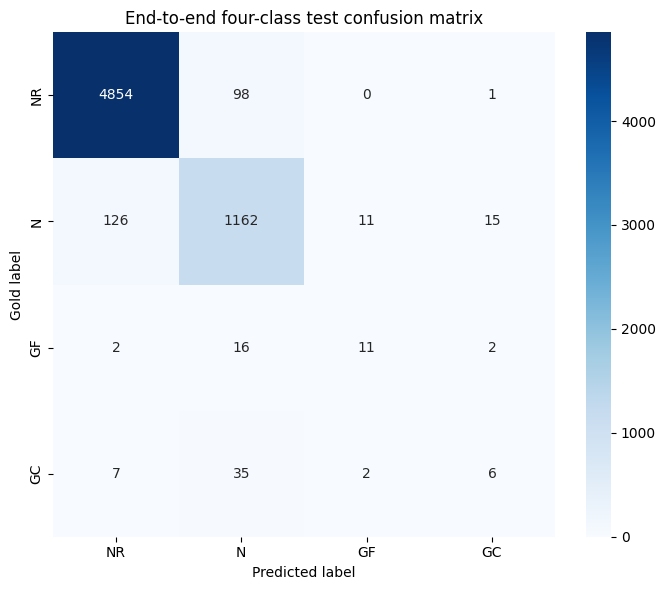

Two-stage error flow


,count,percentage
error_source,,
correct_NR_rejection,4854,76.465028
stage1_false_positive,99,1.559546
stage1_false_negative,135,2.126654
correct_relevant_and_stance,1179,18.572779
stance_error_after_relevance,81,1.275992



Saved end-to-end artifacts:
/kaggle/working/bangla-news-framing/artifacts/end_to_end_test_predictions.csv
/kaggle/working/bangla-news-framing/artifacts/end_to_end_metrics.json
/kaggle/working/bangla-news-framing/artifacts/end_to_end_error_flow.csv
/kaggle/working/bangla-news-framing/artifacts/figures/end_to_end_test_confusion_matrix.png


In [18]:
# Cell 51
# Evaluate the final NR/N/GF/GC predictions and save all artifacts.

def calculate_multiclass_metrics(
    gold_labels,
    predicted_labels,
    label_order,
) -> dict:
    """Return overall and per-class metrics in JSON-safe types."""
    precision, recall, f1, support = (
        precision_recall_fscore_support(
            gold_labels,
            predicted_labels,
            labels=label_order,
            zero_division=0,
        )
    )

    results = {
        "accuracy": float(
            accuracy_score(gold_labels, predicted_labels)
        ),
        "macro_f1": float(
            f1_score(
                gold_labels,
                predicted_labels,
                labels=label_order,
                average="macro",
                zero_division=0,
            )
        ),
        "weighted_f1": float(
            f1_score(
                gold_labels,
                predicted_labels,
                labels=label_order,
                average="weighted",
                zero_division=0,
            )
        ),
        "per_class": {},
    }

    for index, label_name in enumerate(label_order):
        results["per_class"][label_name] = {
            "precision": float(precision[index]),
            "recall": float(recall[index]),
            "f1": float(f1[index]),
            "support": int(support[index]),
        }

    return results


gold_final = test_end_to_end[
    "gold_final_label"
].to_numpy()

predicted_final = test_end_to_end[
    "predicted_final_label"
].to_numpy()

end_to_end_metrics = calculate_multiclass_metrics(
    gold_final,
    predicted_final,
    FINAL_LABELS,
)

# Majority baseline: predict NR for every pair.
majority_predictions = np.full(
    len(test_end_to_end),
    "NR",
    dtype=object,
)

majority_baseline_metrics = calculate_multiclass_metrics(
    gold_final,
    majority_predictions,
    FINAL_LABELS,
)

end_to_end_report = classification_report(
    gold_final,
    predicted_final,
    labels=FINAL_LABELS,
    target_names=FINAL_LABELS,
    output_dict=True,
    zero_division=0,
)

print("End-to-end four-class test metrics")
display(
    pd.Series(
        {
            "accuracy": end_to_end_metrics["accuracy"],
            "macro_f1": end_to_end_metrics["macro_f1"],
            "weighted_f1": end_to_end_metrics["weighted_f1"],
        },
        name="value",
    ).to_frame()
)

print("Per-class test metrics")
display(
    pd.DataFrame(
        end_to_end_metrics["per_class"]
    ).T
)

print("NR-majority baseline")
display(
    pd.Series(
        {
            "accuracy": majority_baseline_metrics["accuracy"],
            "macro_f1": majority_baseline_metrics["macro_f1"],
            "weighted_f1": majority_baseline_metrics["weighted_f1"],
        },
        name="value",
    ).to_frame()
)

end_to_end_confusion = confusion_matrix(
    gold_final,
    predicted_final,
    labels=FINAL_LABELS,
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    end_to_end_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=FINAL_LABELS,
    yticklabels=FINAL_LABELS,
)
plt.title("End-to-end four-class test confusion matrix")
plt.xlabel("Predicted label")
plt.ylabel("Gold label")
plt.tight_layout()

end_to_end_figure_path = (
    FIGURES_DIR
    / "end_to_end_test_confusion_matrix.png"
)

plt.savefig(
    end_to_end_figure_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

# Identify where errors enter the two-stage pipeline.
gold_is_relevant = ~test_end_to_end[
    "gold_final_label"
].eq("NR")

predicted_is_relevant = ~test_end_to_end[
    "predicted_final_label"
].eq("NR")

conditions = [
    (~gold_is_relevant) & (~predicted_is_relevant),
    (~gold_is_relevant) & predicted_is_relevant,
    gold_is_relevant & (~predicted_is_relevant),
    (
        gold_is_relevant
        & predicted_is_relevant
        & test_end_to_end["gold_final_label"].eq(
            test_end_to_end["predicted_final_label"]
        )
    ),
    (
        gold_is_relevant
        & predicted_is_relevant
        & ~test_end_to_end["gold_final_label"].eq(
            test_end_to_end["predicted_final_label"]
        )
    ),
]

error_categories = [
    "correct_NR_rejection",
    "stage1_false_positive",
    "stage1_false_negative",
    "correct_relevant_and_stance",
    "stance_error_after_relevance",
]

test_end_to_end["error_source"] = np.select(
    conditions,
    error_categories,
    default="unclassified",
)

assert not test_end_to_end[
    "error_source"
].eq("unclassified").any()

error_flow_table = (
    test_end_to_end["error_source"]
    .value_counts()
    .reindex(error_categories, fill_value=0)
    .rename("count")
    .to_frame()
)

error_flow_table["percentage"] = (
    error_flow_table["count"]
    .div(len(test_end_to_end))
    .mul(100)
)

print("Two-stage error flow")
display(error_flow_table)

prediction_path = (
    OUTPUT_DIR / "end_to_end_test_predictions.csv"
)
metrics_path = (
    OUTPUT_DIR / "end_to_end_metrics.json"
)
error_flow_path = (
    OUTPUT_DIR / "end_to_end_error_flow.csv"
)

prediction_columns = [
    "article_id",
    "event_name",
    "article_stance",
    "sentence_id",
    "sentence_index",
    "sentence_section",
    "sentence_text_raw",
    "sentence_text_clean",
    "aspect_id",
    "aspect_column",
    "aspect_text",
    "gold_final_label",
    "predicted_relevance_label",
    "predicted_conditional_stance",
    "predicted_final_label",
    "probability_relevant",
    "probability_NR",
    "probability_N",
    "probability_GF",
    "probability_GC",
    "conditional_probability_N",
    "conditional_probability_GF",
    "conditional_probability_GC",
    "joint_argmax_label",
    "hard_gate_matches_joint_argmax",
    "error_source",
    "stance_holder",
    "is_quote",
    "token_length",
]

test_end_to_end[
    prediction_columns
].to_csv(
    prediction_path,
    index=False,
    encoding="utf-8-sig",
)

error_flow_table.to_csv(
    error_flow_path,
    encoding="utf-8-sig",
)

metrics_artifact = {
    "evaluation_scope": (
        "untouched event-grouped test sentence-aspect pairs"
    ),
    "pipeline": (
        "Stage 1 NR/relevant threshold 0.5; "
        "Stage 2 N/GF/GC argmax for predicted-relevant pairs"
    ),
    "relevance_threshold": RELEVANCE_THRESHOLD,
    "label_order": FINAL_LABELS,
    "test_pairs": int(len(test_end_to_end)),
    "test_articles": int(
        test_end_to_end["article_id"].nunique()
    ),
    "test_events": int(
        test_end_to_end["event_name"].nunique()
    ),
    "test_event_names": sorted(
        test_end_to_end["event_name"].unique().tolist()
    ),
    "metrics": end_to_end_metrics,
    "nr_majority_baseline": majority_baseline_metrics,
    "confusion_matrix": end_to_end_confusion.tolist(),
    "error_flow": {
        category: {
            "count": int(error_flow_table.loc[category, "count"]),
            "percentage": float(
                error_flow_table.loc[category, "percentage"]
            ),
        }
        for category in error_categories
    },
    "probability_definition": {
        "NR": "P(NR)",
        "N": "P(relevant) * P(N | relevant)",
        "GF": "P(relevant) * P(GF | relevant)",
        "GC": "P(relevant) * P(GC | relevant)",
    },
    "annotation_status": (
        "AI-assisted labels; GF and GC have very small support, "
        "so directional results are preliminary"
    ),
}

with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(
        metrics_artifact,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("\nSaved end-to-end artifacts:")
print(prediction_path)
print(metrics_path)
print(error_flow_path)
print(end_to_end_figure_path)

In [19]:
# Cell 52
# Generate two-stage probability predictions for all 31,848 pairs.
# Models are loaded sequentially, so they do not share GPU memory.

all_pair_predictions = long_df.copy().reset_index(drop=True)

all_relevance_probabilities, all_relevance_labels = (
    predict_pair_probabilities(
        RELEVANCE_MODEL_DIR,
        all_pair_predictions,
        expected_num_labels=2,
        description="All-pair Stage 1 inference",
    )
)

all_stance_probabilities, all_stance_labels = (
    predict_pair_probabilities(
        STANCE_MODEL_DIR,
        all_pair_predictions,
        expected_num_labels=3,
        description="All-pair Stage 2 inference",
    )
)

assert all_relevance_probabilities.shape == (31848, 2)
assert all_stance_probabilities.shape == (31848, 3)

all_pair_predictions["probability_relevant"] = (
    all_relevance_probabilities[:, 1]
)
all_pair_predictions["conditional_probability_N"] = (
    all_stance_probabilities[:, 0]
)
all_pair_predictions["conditional_probability_GF"] = (
    all_stance_probabilities[:, 1]
)
all_pair_predictions["conditional_probability_GC"] = (
    all_stance_probabilities[:, 2]
)

all_pair_predictions["probability_NR"] = (
    all_relevance_probabilities[:, 0]
)
all_pair_predictions["probability_N"] = (
    all_relevance_probabilities[:, 1]
    * all_stance_probabilities[:, 0]
)
all_pair_predictions["probability_GF"] = (
    all_relevance_probabilities[:, 1]
    * all_stance_probabilities[:, 1]
)
all_pair_predictions["probability_GC"] = (
    all_relevance_probabilities[:, 1]
    * all_stance_probabilities[:, 2]
)

probability_columns = [
    "probability_NR",
    "probability_N",
    "probability_GF",
    "probability_GC",
]

assert np.allclose(
    all_pair_predictions[probability_columns].sum(axis=1),
    1.0,
    atol=1e-5,
)

all_pair_predictions["predicted_relevance_id"] = (
    all_pair_predictions["probability_relevant"]
    .ge(RELEVANCE_THRESHOLD)
    .astype("int8")
)

all_predicted_stance_ids = (
    all_stance_probabilities.argmax(axis=1)
)
all_predicted_stance_labels = np.asarray(
    STANCE_LABELS
)[all_predicted_stance_ids]

all_pair_predictions["predicted_conditional_stance"] = (
    all_predicted_stance_labels
)

all_pair_predictions["predicted_final_label"] = np.where(
    all_pair_predictions["predicted_relevance_id"].eq(0),
    "NR",
    all_predicted_stance_labels,
)

all_pair_predictions["gold_final_label"] = (
    all_pair_predictions["aspect_label"]
)

regenerated_test = (
    all_pair_predictions.loc[
        all_pair_predictions["split"].eq("test")
    ]
    .reset_index(drop=True)
)

assert regenerated_test[
    ["sentence_id", "aspect_id"]
].equals(
    test_end_to_end[
        ["sentence_id", "aspect_id"]
    ]
)

test_label_agreement = (
    regenerated_test["predicted_final_label"]
    .eq(test_end_to_end["predicted_final_label"])
    .mean()
)

assert test_label_agreement == 1.0

all_pair_path = (
    OUTPUT_DIR / "all_pair_probabilities.parquet"
)

all_pair_predictions.to_parquet(
    all_pair_path,
    index=False,
)

print(
    "Relevance probability dimensions:",
    all_relevance_probabilities.shape,
)
print(
    "Conditional stance dimensions:",
    all_stance_probabilities.shape,
)
print(
    "Test-label reproduction agreement:",
    f"{test_label_agreement:.2%}",
)
print("\nPairs by split:")
display(
    all_pair_predictions["split"]
    .value_counts()
    .reindex(SPLIT_ORDER)
    .rename("pairs")
    .to_frame()
)
print("Saved:", all_pair_path)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

All-pair Stage 1 inference:   0%|          | 0/996 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

All-pair Stage 2 inference:   0%|          | 0/996 [00:00<?, ?it/s]

Relevance probability dimensions: (31848, 2)
Conditional stance dimensions: (31848, 3)
Test-label reproduction agreement: 100.00%

Pairs by split:


,pairs
split,
train,21570
validation,3930
test,6348


Saved: /kaggle/working/bangla-news-framing/artifacts/all_pair_probabilities.parquet


In [20]:
# Cell 53
# Aggregate sentence-aspect probabilities into article-aspect profiles.

profile_input = all_pair_predictions.copy()

# Positive values indicate favourable evidence; negative values indicate
# critical evidence toward the government's role.
profile_input["direction_mass"] = (
    profile_input["probability_relevant"]
    * (
        profile_input["conditional_probability_GF"]
        - profile_input["conditional_probability_GC"]
    )
)

article_aspect_profiles = (
    profile_input
    .groupby(
        [
            "article_id",
            "event_name",
            "split",
            "aspect_id",
        ],
        as_index=False,
        observed=True,
    )
    .agg(
        sentence_count=("sentence_id", "nunique"),
        relevance_evidence=("probability_relevant", "sum"),
        emphasis=("probability_relevant", "mean"),
        direction_mass=("direction_mass", "sum"),
        favorable_mass=("probability_GF", "sum"),
        critical_mass=("probability_GC", "sum"),
        neutral_mass=("probability_N", "sum"),
        hard_relevant_count=("predicted_relevance_id", "sum"),
    )
)

# Conditional stance = direction mass / relevance evidence.
article_aspect_profiles["stance"] = np.divide(
    article_aspect_profiles["direction_mass"],
    article_aspect_profiles["relevance_evidence"],
    out=np.zeros(
        len(article_aspect_profiles),
        dtype=float,
    ),
    where=(
        article_aspect_profiles["relevance_evidence"]
        .to_numpy()
        > 1e-12
    ),
)

article_aspect_profiles["coverage_percent"] = (
    article_aspect_profiles["hard_relevant_count"]
    .div(article_aspect_profiles["sentence_count"])
    .mul(100)
)

assert len(article_aspect_profiles) == 118 * 6
assert (
    article_aspect_profiles
    .groupby("article_id")
    .size()
    .eq(6)
    .all()
)
assert article_aspect_profiles["emphasis"].between(0, 1).all()
assert article_aspect_profiles["stance"].between(-1, 1).all()

emphasis_wide = article_aspect_profiles.pivot(
    index="article_id",
    columns="aspect_id",
    values="emphasis",
)
emphasis_wide.columns = [
    f"{aspect_id}_emphasis"
    for aspect_id in emphasis_wide.columns
]

stance_wide = article_aspect_profiles.pivot(
    index="article_id",
    columns="aspect_id",
    values="stance",
)
stance_wide.columns = [
    f"{aspect_id}_stance"
    for aspect_id in stance_wide.columns
]

article_metadata = (
    df[
        [
            "article_id",
            "event_name",
            "split",
            "article_stance",
            "news_source",
            "news_headline",
            "publication_date",
        ]
    ]
    .drop_duplicates("article_id")
    .copy()
)

assert len(article_metadata) == 118

article_profiles = (
    article_metadata
    .merge(
        emphasis_wide.reset_index(),
        on="article_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        stance_wide.reset_index(),
        on="article_id",
        how="left",
        validate="one_to_one",
    )
)

FEATURE_COLUMNS = [
    feature
    for aspect_id in [
        item["aspect_id"] for item in ASPECTS
    ]
    for feature in [
        f"{aspect_id}_emphasis",
        f"{aspect_id}_stance",
    ]
]

assert len(FEATURE_COLUMNS) == 12
assert article_profiles[FEATURE_COLUMNS].notna().all().all()
assert np.isfinite(
    article_profiles[FEATURE_COLUMNS].to_numpy()
).all()

forbidden_features = {
    "article_stance",
    "article_id",
    "event_name",
    "news_source",
    "source_link",
    "sentence_id",
}

assert forbidden_features.isdisjoint(FEATURE_COLUMNS)

article_profile_path = OUTPUT_DIR / "article_profiles.csv"
article_aspect_path = (
    OUTPUT_DIR / "article_aspect_profiles_long.csv"
)

article_profiles.to_csv(
    article_profile_path,
    index=False,
    encoding="utf-8-sig",
)

article_aspect_profiles.to_csv(
    article_aspect_path,
    index=False,
    encoding="utf-8-sig",
)

print(
    "Article feature matrix dimensions:",
    article_profiles[FEATURE_COLUMNS].shape,
)
print("\nArticles by split:")
display(
    article_profiles["split"]
    .value_counts()
    .reindex(SPLIT_ORDER)
    .rename("articles")
    .to_frame()
)

print("\nFirst article profiles:")
display(
    article_profiles[
        [
            "article_id",
            "event_name",
            "split",
            "article_stance",
        ]
        + FEATURE_COLUMNS
    ].head()
)

print("Saved:", article_profile_path)
print("Saved:", article_aspect_path)

Article feature matrix dimensions: (118, 12)

Articles by split:


,articles
split,
train,83
validation,17
test,18



First article profiles:


,article_id,event_name,split,article_stance,A1_emphasis,A1_stance,A2_emphasis,A2_stance,A3_emphasis,A3_stance,A4_emphasis,A4_stance,A5_emphasis,A5_stance,A6_emphasis,A6_stance
0,2,১৯৯৬ একতরফা নির্বাচন,train,Govt critique,0.317501,-0.153629,0.049774,-0.973697,0.073937,-0.328463,0.853769,-0.136638,0.000765,-0.098404,0.000734,-0.091076
1,4,শাহবাগ আন্দোলন,validation,Neutral,0.207779,-0.000135,0.243044,-0.000117,0.070496,-0.000117,0.776528,-0.000120,0.003126,-0.000138,0.121599,-0.000119
2,5,শাহবাগ আন্দোলন,validation,Neutral,0.135606,-0.000555,0.225576,-0.067179,0.091976,-0.007976,0.597166,-0.036669,0.054289,-0.000336,0.102588,-0.000217
3,6,হেফাজতে ইসলামের লংমার্চ ও ঢাকা অবরোধ,train,Govt leaning,0.342539,-0.000224,0.100812,-0.000160,0.391466,-0.000173,0.610171,-0.000148,0.000912,-0.000132,0.172700,-0.000099
4,7,হেফাজতে ইসলামের লংমার্চ ও ঢাকা অবরোধ,train,Neutral,0.298204,-0.035196,0.073757,-0.000326,0.737296,-0.028249,0.614074,-0.000481,0.062769,-0.000380,0.054277,-0.000355


Saved: /kaggle/working/bangla-news-framing/artifacts/article_profiles.csv
Saved: /kaggle/working/bangla-news-framing/artifacts/article_aspect_profiles_long.csv


In [ ]:
# Cell 54
# Select Logistic Regression regularization using event-grouped CV.

import joblib

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

ARTICLE_LABEL_ORDER = [
    "Govt critique",
    "Neutral",
    "Govt leaning",
]

training_profiles = (
    article_profiles.loc[
        article_profiles["split"].eq("train")
    ]
    .copy()
    .reset_index(drop=True)
)

development_profiles = (
    article_profiles.loc[
        article_profiles["split"].isin(
            ["train", "validation"]
        )
    ]
    .copy()
    .reset_index(drop=True)
)

test_article_profiles = (
    article_profiles.loc[
        article_profiles["split"].eq("test")
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(training_profiles) == 83
assert len(development_profiles) == 100
assert len(test_article_profiles) == 18
assert set(
    development_profiles["event_name"]
).isdisjoint(
    set(test_article_profiles["event_name"])
)

X_train_articles = training_profiles[FEATURE_COLUMNS]
y_train_articles = training_profiles["article_stance"]
train_article_groups = training_profiles["event_name"]

X_development = development_profiles[FEATURE_COLUMNS]
y_development = development_profiles["article_stance"]

X_test_articles = test_article_profiles[FEATURE_COLUMNS]
y_test_articles = test_article_profiles["article_stance"]

article_pipeline_template = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                solver="lbfgs",
                max_iter=5000,
                random_state=SEED,
            ),
        ),
    ]
)

def article_macro_f1_scorer(
    estimator,
    features,
    gold_labels,
):
    """
    Score a fitted article classifier with fixed-label macro F1.

    This estimator-based scorer avoids scikit-learn treating the
    string multiclass labels as a binary problem with pos_label=1.
    """
    predicted_labels = estimator.predict(features)

    return f1_score(
        gold_labels,
        predicted_labels,
        labels=ARTICLE_LABEL_ORDER,
        average="macro",
        zero_division=0,
    )

article_group_cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

article_cv_splits = list(
    article_group_cv.split(
        X_train_articles,
        y_train_articles,
        groups=train_article_groups,
    )
)

fold_summary = []

for fold_number, (
    fold_train_indices,
    fold_validation_indices,
) in enumerate(article_cv_splits, start=1):
    fold_train_events = set(
        train_article_groups.iloc[fold_train_indices]
    )
    fold_validation_events = set(
        train_article_groups.iloc[fold_validation_indices]
    )

    assert fold_train_events.isdisjoint(
        fold_validation_events
    )

    fold_validation_labels = (
        y_train_articles.iloc[fold_validation_indices]
        .value_counts()
        .reindex(
            ARTICLE_LABEL_ORDER,
            fill_value=0,
        )
    )

    fold_summary.append(
        {
            "fold": fold_number,
            "training_events": len(fold_train_events),
            "validation_events": len(fold_validation_events),
            "validation_articles": len(fold_validation_indices),
            **{
                f"validation_{label}": int(count)
                for label, count
                in fold_validation_labels.items()
            },
        }
    )

display(pd.DataFrame(fold_summary))

article_parameter_grid = {
    "classifier__C": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0,
    ]
}

article_grid_search = GridSearchCV(
    estimator=article_pipeline_template,
    param_grid=article_parameter_grid,
    scoring=article_macro_f1_scorer,
    cv=article_cv_splits,
    refit=True,
    n_jobs=-1,
    return_train_score=True,
)

article_grid_search.fit(
    X_train_articles,
    y_train_articles,
)

mean_cv_scores = np.asarray(
    article_grid_search.cv_results_["mean_test_score"],
    dtype=float,
)

assert np.isfinite(mean_cv_scores).all(), (
    "Grouped-CV produced a non-finite score. Do not select C or "
    "evaluate the test set until the scoring failure is fixed."
)
assert np.isfinite(article_grid_search.best_score_)

article_cv_results = pd.DataFrame(
    article_grid_search.cv_results_
)

article_cv_results_table = (
    article_cv_results[
        [
            "param_classifier__C",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "rank_test_score",
        ]
    ]
    .rename(
        columns={
            "param_classifier__C": "C",
            "mean_test_score": "cv_macro_f1_mean",
            "std_test_score": "cv_macro_f1_std",
            "mean_train_score": "cv_train_macro_f1_mean",
            "rank_test_score": "rank",
        }
    )
    .sort_values("C")
    .reset_index(drop=True)
)

best_article_c = float(
    article_grid_search.best_params_[
        "classifier__C"
    ]
)

print("Grouped-CV results")
display(article_cv_results_table)
print("Selected C:", best_article_c)
print(
    "Best grouped-CV macro F1:",
    f"{article_grid_search.best_score_:.4f}",
)

# Hyperparameters are frozen before fitting all non-test articles.
final_article_model = clone(
    article_pipeline_template
).set_params(
    classifier__C=best_article_c
)

final_article_model.fit(
    X_development,
    y_development,
)

article_test_predictions = (
    final_article_model.predict(X_test_articles)
)
article_test_probabilities = (
    final_article_model.predict_proba(X_test_articles)
)
article_probability_classes = (
    final_article_model
    .named_steps["classifier"]
    .classes_
)

article_test_metrics = calculate_multiclass_metrics(
    y_test_articles,
    article_test_predictions,
    ARTICLE_LABEL_ORDER,
)

majority_article_label = (
    y_development.value_counts().idxmax()
)
article_majority_predictions = np.full(
    len(y_test_articles),
    majority_article_label,
    dtype=object,
)

article_baseline_metrics = calculate_multiclass_metrics(
    y_test_articles,
    article_majority_predictions,
    ARTICLE_LABEL_ORDER,
)

print("\nArticle-level held-out test metrics")
display(
    pd.Series(
        {
            "accuracy": article_test_metrics["accuracy"],
            "macro_f1": article_test_metrics["macro_f1"],
            "weighted_f1": article_test_metrics["weighted_f1"],
        },
        name="value",
    ).to_frame()
)

print("Article-level per-class test metrics")
display(
    pd.DataFrame(
        article_test_metrics["per_class"]
    ).T
)

print(
    f"Development-majority baseline: "
    f"{majority_article_label}"
)
display(
    pd.Series(
        {
            "accuracy": article_baseline_metrics["accuracy"],
            "macro_f1": article_baseline_metrics["macro_f1"],
            "weighted_f1": article_baseline_metrics["weighted_f1"],
        },
        name="value",
    ).to_frame()
)

In [ ]:
# Cell 55
# Save the article classifier, metrics, predictions, and coefficients.

article_test_output = test_article_profiles[
    [
        "article_id",
        "event_name",
        "news_source",
        "news_headline",
        "article_stance",
    ]
].copy()

article_test_output = article_test_output.rename(
    columns={"article_stance": "gold_article_stance"}
)

article_test_output["predicted_article_stance"] = (
    article_test_predictions
)

for probability_index, class_name in enumerate(
    article_probability_classes
):
    safe_class_name = (
        class_name.lower().replace(" ", "_")
    )
    article_test_output[
        f"probability_{safe_class_name}"
    ] = article_test_probabilities[:, probability_index]

article_test_output["is_correct"] = (
    article_test_output["gold_article_stance"]
    .eq(article_test_output["predicted_article_stance"])
)

article_confusion = confusion_matrix(
    y_test_articles,
    article_test_predictions,
    labels=ARTICLE_LABEL_ORDER,
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    article_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=ARTICLE_LABEL_ORDER,
    yticklabels=ARTICLE_LABEL_ORDER,
)
plt.title("Article-level held-out test confusion matrix")
plt.xlabel("Predicted article stance")
plt.ylabel("Gold article stance")
plt.tight_layout()

article_confusion_path = (
    FIGURES_DIR
    / "article_test_confusion_matrix.png"
)

plt.savefig(
    article_confusion_path,
    dpi=200,
    bbox_inches="tight",
)
plt.show()

print("Article-level classification report")
display(
    pd.DataFrame(
        classification_report(
            y_test_articles,
            article_test_predictions,
            labels=ARTICLE_LABEL_ORDER,
            target_names=ARTICLE_LABEL_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).T
)

# Coefficients correspond to standardized article-profile features.
article_classifier = (
    final_article_model.named_steps["classifier"]
)

article_coefficients = pd.DataFrame(
    article_classifier.coef_,
    index=article_classifier.classes_,
    columns=FEATURE_COLUMNS,
)

print("Standardized Logistic Regression coefficients")
display(article_coefficients)

article_model_path = (
    OUTPUT_DIR / "article_classifier.joblib"
)
article_metrics_path = (
    OUTPUT_DIR / "article_metrics.json"
)
article_predictions_path = (
    OUTPUT_DIR / "article_test_predictions.csv"
)
article_cv_path = (
    OUTPUT_DIR / "article_grouped_cv_results.csv"
)
article_coefficients_path = (
    OUTPUT_DIR / "article_classifier_coefficients.csv"
)

joblib.dump(
    final_article_model,
    article_model_path,
)

article_test_output.to_csv(
    article_predictions_path,
    index=False,
    encoding="utf-8-sig",
)

article_cv_results_table.to_csv(
    article_cv_path,
    index=False,
    encoding="utf-8-sig",
)

article_coefficients.to_csv(
    article_coefficients_path,
    encoding="utf-8-sig",
)

article_metrics_artifact = {
    "classifier": (
        "StandardScaler plus class-balanced Logistic Regression"
    ),
    "features": FEATURE_COLUMNS,
    "feature_count": len(FEATURE_COLUMNS),
    "aggregation": (
        "unweighted probability-based emphasis and "
        "conditional stance for six aspects"
    ),
    "hyperparameter_selection": (
        "5-fold StratifiedGroupKFold on training events"
    ),
    "selected_C": best_article_c,
    "best_cv_macro_f1_mean": float(
        article_grid_search.best_score_
    ),
    "cv_results": [
        {
            "C": float(row["C"]),
            "macro_f1_mean": float(
                row["cv_macro_f1_mean"]
            ),
            "macro_f1_std": float(
                row["cv_macro_f1_std"]
            ),
        }
        for _, row in article_cv_results_table.iterrows()
    ],
    "final_fit_articles": int(
        len(development_profiles)
    ),
    "final_fit_events": int(
        development_profiles["event_name"].nunique()
    ),
    "test_articles": int(len(test_article_profiles)),
    "test_events": int(
        test_article_profiles["event_name"].nunique()
    ),
    "test_metrics": article_test_metrics,
    "majority_baseline_label": majority_article_label,
    "majority_baseline_metrics": article_baseline_metrics,
    "confusion_matrix": article_confusion.tolist(),
    "label_order": ARTICLE_LABEL_ORDER,
    "methodological_note": (
        "Test events were not used to fit or select the article "
        "classifier. Training-event profiles are generated by "
        "sentence models fitted on sentence labels from those events, "
        "so classifier CV is exploratory rather than fully cross-fitted."
    ),
    "annotation_status": (
        "Sentence labels are AI-assisted, and GF/GC examples are scarce."
    ),
}

with article_metrics_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        article_metrics_artifact,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("\nSaved article-level artifacts:")
print(article_profile_path)
print(article_model_path)
print(article_metrics_path)
print(article_predictions_path)
print(article_cv_path)
print(article_coefficients_path)
print(article_confusion_path)